# Geometria dos Espaços de Embedding em Sistemas de Recomendação
## Análise Comparativa de GNNs e Transformers — BraSNAM Revision

Notebook consolidado contendo **LightGCN**, **KGAT (com atenção)** e **SASRec (full-corpus eval)** para a revisão do artigo do BraSNAM.

### Principais mudanças em relação aos notebooks originais

| Mudança | Motivação |
|---|---|
| **KGAT com atenção TransR** (era Bi-Interaction GCN sem atenção) | A implementação anterior não era KGAT — o mecanismo de atenção do paper (Wang et al. 2019a, Eq. 4-5) estava ausente. Cross-validado com [LunaBlack/KGAT-pytorch](https://github.com/LunaBlack/KGAT-pytorch). |
| **SASRec com full-corpus evaluation** (era sampled 1+100 negativos) | A avaliação amostrada (Krichene & Rendle, 2020) torna HR@10/NDCG@10 incomparáveis com LightGCN/KGAT, que avaliam contra todo o catálogo. |
| **SASRec apenas em ML-1M** | Yelp2018 e Amazon-Book do LightGCN repo não têm ordem cronológica preservada, invalidando o uso sequencial. |
| **KGAT eval em todos os usuários** (era amostra de 1000) | A amostra anterior era não-determinística e não reproduzível. |
| **NP@10 e LDD@10 com grafo de interação como referência** (era o próprio embedding) | A definição anterior media fidelidade do t-SNE ao embedding, não a estrutura intrínseca dos dados. A nova definição responde diretamente à crítica dos revisores. |
| **LightGCN também avaliado com NP/LDD** (não estava sendo) | Os valores anteriores da Tabela 3 para LightGCN não tinham origem clara. Agora todos os modelos são avaliados com a mesma definição. |

### Estrutura do notebook

- **Seção 1** — Setup e configuração
- **Seção 2** — Download e preparação de datasets
- **Seção 3** — Métricas (HR, Recall, NDCG full-corpus + NP/LDD geométricas)
- **Seção 4** — LightGCN (modelo, treino, avaliação)
- **Seção 5** — KGAT com mecanismo de atenção do paper
- **Seção 6** — SASRec com avaliação full-corpus
- **Seção 7** — Análise geométrica e visualizações t-SNE
- **Seção 8** — Experimentos principais (Tabelas A, B, C)

### Protocolos experimentais

- **Tabela A (next-item prediction)**: divisão cronológica leave-one-out, eval full-corpus, **apenas ML-1M**, três modelos.
- **Tabela B (recomendação geral)**: divisão aleatória 80/20, eval full-corpus, **três datasets**, LightGCN e KGAT.
- **Tabela C (geometria)**: NP@10 e LDD@10 com grafo de interação como referência.

Todos os experimentos usam **3 seeds** (2020, 2021, 2022) e reportam **média ± desvio padrão**.


## 1. Setup e Configuração

In [3]:
# Google Drive mount (Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/brasnam_experiments'
except Exception:
    SAVE_DIR = './brasnam_experiments'

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/brasnam_experiments


In [4]:
# Install packages (run once per Colab session)
!pip install -q torch torchvision torchaudio
!pip install -q scipy scikit-learn pandas numpy tqdm matplotlib seaborn requests

In [5]:
# Core imports
import os, sys, time, random, json, gc, copy, pickle, warnings
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime
import multiprocessing
from multiprocessing import Process, Queue

import numpy as np
import pandas as pd
import requests
import zipfile
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import scipy.sparse as sp
from scipy.sparse import csr_matrix, dok_matrix
from scipy.spatial.distance import pdist, squareform

from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

In [6]:
# Device check
if not torch.cuda.is_available():
    print("WARNING: CUDA not available. Training will be very slow.")
    DEVICE = torch.device('cpu')
else:
    DEVICE = torch.device('cuda')
    print(f"CUDA: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

CUDA: NVIDIA L4
Memory: 22.0 GB


In [7]:
# Seed control
def set_seed(seed=2020):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEEDS = [2020, 2021, 2022]   # used by all experiments
set_seed(SEEDS[0])

# Data paths
DATA_ROOT = Path('data')
DATA_ROOT.mkdir(exist_ok=True)
print(f"Data root: {DATA_ROOT.absolute()}")

Data root: /content/data


## 2. Preparação dos Datasets

Esta seção baixa e prepara os três datasets nos formatos necessários:

- **Yelp2018** e **Amazon-Book** vêm dos repositórios oficiais do KGAT (`xiangwang1223/knowledge_graph_attention_network`) e do LightGCN (`gusye1234/LightGCN-PyTorch`). Ambos disponibilizam `train.txt`/`test.txt` no formato `user_id item1 item2 ...` com **divisão aleatória 80/20**. O KGAT repo adicionalmente fornece `kg_final.txt` com triplas (head, relation, tail) construídas a partir do Freebase.

- **MovieLens-1M** vem da fonte original (`grouplens.org`). Construímos duas versões:
  1. **Random split 80/20** — para recomendação geral (Tabela B).
  2. **Chronological leave-one-out** — para next-item prediction (Tabela A). Usa timestamps para ordenar cada sequência de usuário e separa último item para teste, penúltimo para validação.
  
  Para o KGAT no ML-1M, construímos o KG a partir dos metadados de gênero (`movies.dat`), criando triplas `(movie_id, has_genre, genre_id)`. Esta é uma escolha consciente — o ML-1M não tem KG externo disponível como Yelp/Amazon, então temos apenas uma relação. Isso será documentado explicitamente no paper.

In [8]:
# ---------- Yelp2018 and Amazon-Book (general recommendation splits + KG) ----------

KGAT_BASE = "https://github.com/xiangwang1223/knowledge_graph_attention_network/raw/master/Data"

def download_file(url, dest):
    """Download a single file with basic error handling."""
    dest = Path(dest)
    if dest.exists():
        return True
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        r = requests.get(url, stream=True, timeout=60)
        r.raise_for_status()
        with open(dest, 'wb') as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)
        return True
    except Exception as e:
        print(f"  Failed: {url} -> {e}")
        if dest.exists():
            dest.unlink()
        return False

def download_kgat_dataset(name):
    """Download train/test/KG/relation files for yelp2018 or amazon-book from the KGAT repo."""
    d = DATA_ROOT / name
    d.mkdir(parents=True, exist_ok=True)

    # train.txt and test.txt
    for fname in ['train.txt', 'test.txt']:
        url = f"{KGAT_BASE}/{name}/{fname}"
        ok = download_file(url, d / fname)
        if not ok:
            print(f"  Could not get {fname} for {name}")

    # relation_list.txt (saved as relation.txt for consistency)
    download_file(f"{KGAT_BASE}/{name}/relation_list.txt", d / 'relation.txt')
    download_file(f"{KGAT_BASE}/{name}/entity_list.txt", d / 'entity_list.txt')

    # kg_final.txt — tries .zip first, falls back to .txt
    kg_dest = d / 'kg_final.txt'
    if not kg_dest.exists():
        zip_url = f"{KGAT_BASE}/{name}/kg_final.txt.zip"
        zip_dest = d / 'kg_final.txt.zip'
        if download_file(zip_url, zip_dest):
            try:
                with zipfile.ZipFile(zip_dest, 'r') as zf:
                    zf.extractall(d)
                zip_dest.unlink()
            except Exception as e:
                print(f"  Zip extract failed: {e}")
        if not kg_dest.exists():
            download_file(f"{KGAT_BASE}/{name}/kg_final.txt", kg_dest)

    if (d / 'train.txt').exists() and (d / 'kg_final.txt').exists():
        print(f"  {name}: OK")
    else:
        print(f"  {name}: INCOMPLETE — check network")

for name in ['yelp2018', 'amazon-book']:
    print(f"Setting up {name}...")
    download_kgat_dataset(name)

Setting up yelp2018...
  yelp2018: OK
Setting up amazon-book...
  amazon-book: OK


In [9]:
# ---------- MovieLens-1M: download both formats we need ----------

ML1M_DIR = DATA_ROOT / 'ml-1m'
ML1M_DIR.mkdir(parents=True, exist_ok=True)

# (A) Sequential format from pmixer/SASRec.pytorch (1-indexed, sorted by timestamp).
#     Used directly by SASRec; converted by LightGCN/KGAT loaders.
ML1M_SEQ_URL = "https://raw.githubusercontent.com/pmixer/SASRec.pytorch/main/python/data/ml-1m.txt"
ml1m_seq_path = ML1M_DIR / 'ml-1m.txt'
if not ml1m_seq_path.exists():
    print("Downloading ML-1M (sequential format)...")
    download_file(ML1M_SEQ_URL, ml1m_seq_path)

# (B) Original ML-1M with metadata (for KGAT KG construction)
ML1M_ZIP_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
ml1m_orig_dir = DATA_ROOT / 'ml-1m-original'
ml1m_orig_dir.mkdir(parents=True, exist_ok=True)
if not (ml1m_orig_dir / 'ml-1m' / 'movies.dat').exists():
    print("Downloading ML-1M (original with metadata)...")
    zip_path = ml1m_orig_dir / 'ml-1m.zip'
    download_file(ML1M_ZIP_URL, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(ml1m_orig_dir)
    zip_path.unlink()
print("  ML-1M files ready.")

  ML-1M files ready.


In [10]:
# ---------- ML-1M splits ----------
#
# We need TWO versions of ML-1M splits:
#
#   1. CHRONOLOGICAL LEAVE-ONE-OUT (for Table A, next-item prediction)
#      For each user, sort interactions by timestamp; train = first n-2,
#      valid = item at position n-2, test = item at position n-1.
#      Output: train.txt / valid.txt / test.txt in "user id1 id2 ..." format.
#
#   2. RANDOM 80/20 (for Table B, general recommendation)
#      For each user, randomly split their interactions 80/20.
#      Output: train.txt / test.txt in "user id1 id2 ..." format.
#
# Both versions use 0-indexed user IDs and 0-indexed item IDs (LightGCN convention).
# Item IDs are remapped to be contiguous (0 to n_items-1) using only items that
# appear in the data.

def build_ml1m_loo_split(out_dir):
    """Chronological leave-one-out split for ML-1M."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if (out_dir / 'train.txt').exists() and (out_dir / 'test.txt').exists():
        print(f"  LOO split already at {out_dir}")
        return

    # pmixer's ml-1m.txt is already chronologically ordered (sorted by timestamp).
    # Format: 1-indexed "user_id item_id" per line.
    print(f"Building chronological LOO split at {out_dir}...")
    user_seq = defaultdict(list)
    with open(ml1m_seq_path) as f:
        for line in f:
            u, i = line.strip().split()
            user_seq[int(u) - 1].append(int(i) - 1)  # convert to 0-indexed

    train_d, valid_d, test_d = {}, {}, {}
    for u, seq in user_seq.items():
        if len(seq) < 3:
            train_d[u] = seq            # not enough for valid/test
        else:
            train_d[u] = seq[:-2]
            valid_d[u] = [seq[-2]]
            test_d[u]  = [seq[-1]]

    def write_split(d, path):
        with open(path, 'w') as f:
            for u in sorted(d.keys()):
                f.write(f"{u} " + ' '.join(map(str, d[u])) + "\n")

    write_split(train_d, out_dir / 'train.txt')
    write_split(valid_d, out_dir / 'valid.txt')
    write_split(test_d,  out_dir / 'test.txt')
    print(f"  Done. {len(train_d)} users, "
          f"{sum(len(v) for v in train_d.values())} train interactions.")


def build_ml1m_random_split(out_dir, test_size=0.2, seed=2020):
    """Per-user random split for ML-1M."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if (out_dir / 'train.txt').exists() and (out_dir / 'test.txt').exists():
        print(f"  Random split already at {out_dir}")
        return

    print(f"Building random {1 - test_size:.0%}/{test_size:.0%} split at {out_dir}...")
    rng = np.random.RandomState(seed)
    user_seq = defaultdict(list)
    with open(ml1m_seq_path) as f:
        for line in f:
            u, i = line.strip().split()
            user_seq[int(u) - 1].append(int(i) - 1)

    train_d, test_d = {}, {}
    for u, items in user_seq.items():
        if len(items) < 2:
            train_d[u] = items
            continue
        items = items.copy()
        rng.shuffle(items)
        split = max(1, int(len(items) * (1 - test_size)))
        train_d[u] = items[:split]
        test_d[u]  = items[split:]

    def write_split(d, path):
        with open(path, 'w') as f:
            for u in sorted(d.keys()):
                if d[u]:
                    f.write(f"{u} " + ' '.join(map(str, d[u])) + "\n")

    write_split(train_d, out_dir / 'train.txt')
    write_split(test_d,  out_dir / 'test.txt')
    print(f"  Done. {len(train_d)} users, "
          f"{sum(len(v) for v in train_d.values())} train, "
          f"{sum(len(v) for v in test_d.values())} test.")


# Build both versions
build_ml1m_loo_split(DATA_ROOT / 'ml-1m-loo')
build_ml1m_random_split(DATA_ROOT / 'ml-1m-random', test_size=0.2, seed=2020)

Building chronological LOO split at data/ml-1m-loo...
  Done. 6040 users, 987531 train interactions.
Building random 80%/20% split at data/ml-1m-random...
  Done. 6040 users, 797275 train, 202336 test.


In [11]:
# ---------- KG construction for ML-1M (used by KGAT only) ----------
#
# Builds (movie -> genre) triples with a single relation `has_genre`.
# Output: data/ml-1m-{loo,random}/kg_final.txt
#
# We need to map original MovieLens IDs to the 0-indexed item IDs used in our
# splits. pmixer's preprocessing renames items based on order of first
# appearance — we replicate that mapping here for consistency.

def build_ml1m_kg(out_dir):
    """Construct a single-relation KG (movie -> genre) for ML-1M."""
    out_dir = Path(out_dir)
    kg_path = out_dir / 'kg_final.txt'
    if kg_path.exists():
        print(f"  KG already at {kg_path}")
        return

    print(f"Building ML-1M KG at {kg_path}...")
    movies_dat = ml1m_orig_dir / 'ml-1m' / 'movies.dat'
    movies = pd.read_csv(movies_dat, sep='::', header=None,
                         names=['movieId', 'title', 'genres'],
                         engine='python', encoding='latin-1')

    # Recover pmixer's item-ID mapping from the sequential file:
    #   pmixer renumbers movies in order of first appearance in ratings,
    #   producing IDs 1..n_items (we converted to 0..n_items-1 already).
    pmixer_map = {}  # original movieId -> our 0-indexed item id
    with open(ml1m_seq_path) as f:
        for line in f:
            u, i = line.strip().split()
            # The pmixer file stores already-remapped item IDs, not original
            # movie IDs. We need to rebuild the mapping from ratings.dat.

    # Reconstruct from ratings.dat in original order (sorted by timestamp)
    ratings = pd.read_csv(ml1m_orig_dir / 'ml-1m' / 'ratings.dat',
                          sep='::', header=None,
                          names=['userId', 'movieId', 'rating', 'timestamp'],
                          engine='python')
    ratings = ratings.sort_values('timestamp')
    seen = {}
    next_id = 0
    for mid in ratings['movieId']:
        if mid not in seen:
            seen[mid] = next_id
            next_id += 1
    pmixer_map = seen  # original movieId -> 0-indexed item id

    # Genre vocabulary -> entity IDs after items
    n_items = len(pmixer_map)
    all_genres = sorted(set(g for gs in movies['genres'] for g in gs.split('|')))
    genre_map = {g: n_items + i for i, g in enumerate(all_genres)}

    # Write triples
    HAS_GENRE = 0
    with open(kg_path, 'w') as f:
        for _, row in movies.iterrows():
            if row['movieId'] in pmixer_map:
                h = pmixer_map[row['movieId']]
                for g in row['genres'].split('|'):
                    f.write(f"{h}\t{HAS_GENRE}\t{genre_map[g]}\n")

    # Helper files
    with open(out_dir / 'entity_list.txt', 'w') as f:
        for mid, iid in pmixer_map.items():
            f.write(f"m{mid}\t{iid}\n")
        for g, eid in genre_map.items():
            f.write(f"genre:{g}\t{eid}\n")
    with open(out_dir / 'relation.txt', 'w') as f:
        f.write("has_genre\t0\n")

    print(f"  Done. {n_items} items, {len(all_genres)} genres, "
          f"{n_items + len(all_genres)} entities, 1 relation.")


# Build KG for both ML-1M variants (same KG, different splits)
build_ml1m_kg(DATA_ROOT / 'ml-1m-loo')
build_ml1m_kg(DATA_ROOT / 'ml-1m-random')

Building ML-1M KG at data/ml-1m-loo/kg_final.txt...
  Done. 3706 items, 18 genres, 3724 entities, 1 relation.
Building ML-1M KG at data/ml-1m-random/kg_final.txt...
  Done. 3706 items, 18 genres, 3724 entities, 1 relation.


## 3. Métricas e Avaliação

### Métricas de recomendação (full-corpus)

Para todos os modelos, a avaliação ranqueia o item-alvo (ou conjunto de itens-alvo) contra **todos os itens do catálogo** (excluindo aqueles que o usuário já interagiu no treino). As métricas reportadas são:

- **HR@K** (Hit Rate): fração de usuários para os quais ao menos um item de teste está no top-K. Métrica binária por usuário.
- **Recall@K**: média sobre usuários de `(# hits em top-K) / (# itens de teste do usuário)`. Em leave-one-out (|teste|=1), HR@K = Recall@K.
- **NDCG@K**: ganho cumulativo descontado normalizado, padrão da literatura.

### Métricas geométricas (NP@k e LDD@k)

A definição usada no notebook original tinha um problema metodológico: a "alta dimensão" era o próprio embedding do modelo, e a "baixa dimensão" era a projeção t-SNE — então NP/LDD na verdade mediam a fidelidade do **t-SNE**, não a estrutura aprendida pelo modelo.

**Nova definição** (responde diretamente à crítica dos Revisores 1 e 3):

- **Espaço de referência** (high-dim): grafo de interação. Para cada par de itens (i, j), calculamos a similaridade de Jaccard entre os conjuntos de usuários que interagiram com cada um:

  $$\text{sim}(i, j) = \frac{|U(i) \cap U(j)|}{|U(i) \cup U(j)|}$$

  Em palavras: dois itens são "vizinhos" se conjuntos parecidos de usuários os consumiram. Esta é a estrutura colaborativa intrínseca do dataset, antes de qualquer modelo.

- **Espaço de embedding** (target): a representação do item aprendida pelo modelo. Usamos similaridade de cosseno entre vetores de embedding.

- **NP@k** (Neighborhood Preservation): para cada item i, comparamos os k vizinhos mais próximos no espaço de referência (`Ref_k(i)`) com os k mais próximos no espaço de embedding (`Emb_k(i)`):

  $$\text{NP@k} = \frac{1}{N}\sum_{i=1}^{N} \frac{|\text{Ref}_k(i) \cap \text{Emb}_k(i)|}{k}$$

  NP@k ∈ [0, 1]. Valores próximos de 1 indicam que o embedding preserva muito bem a estrutura colaborativa local; valores próximos de 0 indicam que a estrutura geométrica do embedding não reflete a estrutura de interação.

- **LDD@k** (Local Distance Distortion): para cada item i e seus k vizinhos de referência, mede o desvio entre as distâncias na referência e no embedding. Usamos distâncias bounded em [0, 1] (1 - Jaccard e 1 - cosseno) para que sejam diretamente comparáveis:

  $$\text{LDD@k}(i) = \frac{\sum_{j \in \text{Ref}_k(i)} |d_{\text{ref}}(i,j) - d_{\text{emb}}(i,j)|}{\sum_{j \in \text{Ref}_k(i)} d_{\text{ref}}(i,j)}$$

  Menor é melhor; valor próximo de 0 indica que as distâncias locais são preservadas com fidelidade.

### Construção da referência

Como Yelp/Amazon-Book têm ~10⁴–10⁵ itens, computar Jaccard pairwise completo seria custoso. **Amostramos 1000 itens** (mantendo a semente fixa) e calculamos Jaccard de cada item amostrado contra todos os outros do catálogo, ranqueando para extrair os top-k vizinhos. Esta é a mesma estratégia de amostragem usada para t-SNE no paper, garantindo consistência entre métricas e visualizações.

In [12]:
# ---------- Full-corpus evaluation primitives ----------
#
# We expose ONE evaluator that all three models use. It takes:
#   - score_fn(user_ids) -> tensor (B, n_items) of relevance scores
#   - test_dict: {user_id: [item_ids ...]}
#   - train_dict: {user_id: [item_ids ...]} (items to exclude from ranking)
#   - n_items, ks
# It returns dict of {metric@k: value}.
#
# This unified evaluator ensures LightGCN, KGAT, and SASRec are measured the
# same way on full-corpus ranking.

def full_corpus_eval(score_fn, test_dict, train_dict, n_items, ks=(10, 20),
                     batch_users=4096, device=None):
    """
    Evaluate by ranking against the full item catalog.

    score_fn: callable that takes a tensor of user_ids (B,) on `device` and
              returns a tensor (B, n_items) of scores. Higher = better.
    """
    device = device or DEVICE
    users = [u for u in test_dict.keys() if test_dict.get(u)]
    metrics = {f'recall@{k}': [] for k in ks}
    metrics.update({f'hr@{k}': [] for k in ks})
    metrics.update({f'ndcg@{k}': [] for k in ks})
    max_k = max(ks)

    log_factors = 1.0 / np.log2(np.arange(2, max_k + 2))

    with torch.no_grad():
        for i in range(0, len(users), batch_users):
            batch = users[i:i + batch_users]
            user_t = torch.tensor(batch, dtype=torch.long, device=device)
            scores = score_fn(user_t)              # (B, n_items)
            scores = scores.detach()

            # Mask training items (so they can't be predicted)
            for j, u in enumerate(batch):
                train_items = train_dict.get(u, [])
                if train_items:
                    scores[j, train_items] = -float('inf')

            _, top_idx = torch.topk(scores, k=max_k, dim=1)
            top_idx = top_idx.cpu().numpy()

            for j, u in enumerate(batch):
                gt = test_dict[u]
                gt_set = set(gt)
                rec = top_idx[j]

                # Binary relevance at each rank position (length max_k)
                hits = np.array([1.0 if r in gt_set else 0.0 for r in rec])

                for k in ks:
                    hits_k = hits[:k]
                    n_hit = hits_k.sum()
                    # Recall
                    metrics[f'recall@{k}'].append(n_hit / len(gt))
                    # HR (binary)
                    metrics[f'hr@{k}'].append(1.0 if n_hit > 0 else 0.0)
                    # NDCG
                    dcg = (hits_k * log_factors[:k]).sum()
                    # IDCG: ideal is all relevant at top, up to min(|gt|, k)
                    ideal = min(len(gt), k)
                    if ideal == 0:
                        ndcg = 0.0
                    else:
                        idcg = log_factors[:ideal].sum()
                        ndcg = dcg / idcg
                    metrics[f'ndcg@{k}'].append(ndcg)

    return {m: float(np.mean(v)) for m, v in metrics.items()}

In [13]:
# ---------- Geometric metrics with interaction graph as reference ----------

def build_item_user_matrix(train_dict, n_items):
    """Build sparse n_items x n_users matrix from train interactions."""
    users = sorted(train_dict.keys())
    user2idx = {u: i for i, u in enumerate(users)}
    rows, cols = [], []
    for u, items in train_dict.items():
        ui = user2idx[u]
        for it in items:
            if 0 <= it < n_items:
                rows.append(it)
                cols.append(ui)
    data = np.ones(len(rows), dtype=np.float32)
    return sp.csr_matrix((data, (rows, cols)), shape=(n_items, len(users)))


def jaccard_top_k(item_user_matrix, sample_ids, k, batch=256):
    """
    For each item in sample_ids, return the top-k items (excluding itself)
    by Jaccard similarity with all items in item_user_matrix.

    Returns:
        neighbors: (len(sample_ids), k) int array of item IDs
        sims:      (len(sample_ids), k) float array of Jaccard sims
    """
    M = item_user_matrix.astype(np.float32)
    # |U(i)| for each item
    degrees = np.array(M.sum(axis=1)).flatten()      # (n_items,)

    n = len(sample_ids)
    neighbors = np.full((n, k), -1, dtype=np.int64)
    sims = np.zeros((n, k), dtype=np.float32)

    for start in range(0, n, batch):
        end = min(start + batch, n)
        sub = sample_ids[start:end]
        Msub = M[sub]                                # (B, n_users)
        # Intersection counts: (B, n_items)
        inter = Msub.dot(M.T).toarray()
        # Union counts: |U(i)| + |U(j)| - |U(i) ∩ U(j)|
        deg_sub = degrees[sub][:, None]              # (B, 1)
        union = deg_sub + degrees[None, :] - inter   # (B, n_items)
        # Avoid divide-by-zero (items with no users)
        with np.errstate(divide='ignore', invalid='ignore'):
            jacc = np.where(union > 0, inter / union, 0.0)
        # Exclude self
        for j, item_id in enumerate(sub):
            jacc[j, item_id] = -1.0
        # Top-k
        top = np.argpartition(-jacc, kth=k, axis=1)[:, :k]
        for j in range(end - start):
            ranks = top[j]
            ranked = ranks[np.argsort(-jacc[j, ranks])]
            neighbors[start + j] = ranked
            sims[start + j] = jacc[j, ranked]
    return neighbors, sims


def cosine_top_k(embeddings, sample_ids, k):
    """
    For each item in sample_ids, return the top-k items by cosine similarity
    in `embeddings` (full catalog).
    """
    emb = np.asarray(embeddings, dtype=np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    emb_n = emb / norms

    sub = emb_n[sample_ids]                          # (B, d)
    cos = sub @ emb_n.T                              # (B, n_items)
    # Exclude self
    for j, item_id in enumerate(sample_ids):
        cos[j, item_id] = -2.0

    top = np.argpartition(-cos, kth=k, axis=1)[:, :k]
    neighbors = np.full((len(sample_ids), k), -1, dtype=np.int64)
    sims = np.zeros((len(sample_ids), k), dtype=np.float32)
    for j in range(len(sample_ids)):
        ranks = top[j]
        ranked = ranks[np.argsort(-cos[j, ranks])]
        neighbors[j] = ranked
        sims[j] = cos[j, ranked]
    return neighbors, sims


def neighborhood_preservation_and_ldd(embeddings, train_dict, n_items,
                                      n_samples=1000, k=10, seed=2020):
    """
    Compute NP@k and LDD@k using the interaction graph (Jaccard) as the
    reference space and cosine distance in embeddings as the target.

    Reference: item -> top-k items by Jaccard sim of their user sets
    Target:    item -> top-k items by cosine sim of embeddings

    Returns dict with NP@k, LDD@k, and the sample indices used (so the same
    samples can be reused for t-SNE).
    """
    rng = np.random.RandomState(seed)

    # Restrict samples to items that actually have users (otherwise Jaccard is
    # undefined and the metric is uninformative).
    item_user = build_item_user_matrix(train_dict, n_items)
    item_degree = np.array(item_user.sum(axis=1)).flatten()
    valid_items = np.where(item_degree > 0)[0]
    n_samples = min(n_samples, len(valid_items))
    sample = rng.choice(valid_items, size=n_samples, replace=False)
    sample.sort()

    ref_neighbors, ref_sims = jaccard_top_k(item_user, sample, k=k)
    emb_neighbors, emb_sims = cosine_top_k(embeddings, sample, k=k)

    # NP@k
    np_scores = []
    for i in range(n_samples):
        np_scores.append(len(set(ref_neighbors[i]) & set(emb_neighbors[i])) / k)
    np_at_k = float(np.mean(np_scores))

    # LDD@k: both distances bounded in [0, 1].
    # d_ref(i, j) = 1 - jaccard(i, j)
    # d_emb(i, j) = (1 - cos(i, j)) / 2  ->  bounded in [0, 1]
    #
    # For each sample item i and its k Jaccard neighbors j:
    #   numerator = sum_j |d_ref(i,j) - d_emb(i,j)|
    #   denominator = sum_j d_ref(i,j)
    emb_arr = np.asarray(embeddings, dtype=np.float32)
    norms = np.linalg.norm(emb_arr, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    emb_n = emb_arr / norms

    ldd_scores = []
    for i, item_id in enumerate(sample):
        ref_idx = ref_neighbors[i]
        d_ref = 1.0 - ref_sims[i]                            # (k,)
        cos_ij = emb_n[item_id] @ emb_n[ref_idx].T           # (k,)
        d_emb = (1.0 - cos_ij) / 2.0
        denom = d_ref.sum()
        if denom > 1e-9:
            ldd_scores.append(float(np.abs(d_ref - d_emb).sum() / denom))
    ldd_at_k = float(np.mean(ldd_scores)) if ldd_scores else 0.0

    return {
        f'NP@{k}': np_at_k,
        f'LDD@{k}': ldd_at_k,
        'sample_indices': sample,
    }

## 4. LightGCN

Implementação consistente com o paper original (He et al. 2020) e o repo oficial [gusye1234/LightGCN-PyTorch](https://github.com/gusye1234/LightGCN-PyTorch).

### Notas de implementação

- **Peso de camada α_k**: usamos `torch.mean` sobre as K+1 camadas (incluindo a camada 0). Isso é matematicamente equivalente a α_k = 1/(K+1) uniforme para todas as camadas — exatamente o padrão recomendado no paper original. *(Resposta à pergunta do Revisor 1 sobre α_k.)*
- **Normalização da matriz de adjacência**: simétrica `D^(-1/2) A D^(-1/2)`, sem self-loops, sobre o grafo bipartido (N+M)×(N+M) onde N=usuários e M=itens.
- **Loss**: BPR com `softplus(neg - pos)`, equivalente a -log σ(pos-neg). Regularização L2 apenas nos *ego embeddings* (camada 0), com peso 1e-4.
- **Otimizador**: Adam, lr=0.001 (defaults do paper).
- **Treinamento**: 1000 épocas com early stopping baseado em Recall@20 (paciência de 10 avaliações).
- **Avaliação**: full-corpus para todos os splits, usando o evaluator unificado da Seção 3.
- **Amostragem negativa**: 1 negativo por positivo por época, uniforme aleatório, com rejeição de colisões com itens positivos do usuário.
- **Critério de parada**: early stopping com paciência de 10 avaliações (50 épocas) sem melhora em Recall@20.

In [14]:
# ---------- LightGCN dataset (supports both random and LOO splits) ----------
#
# Reads pre-split train.txt/test.txt (and optionally valid.txt) in the format:
#   user_id item1 item2 ...
# All IDs are 0-indexed.

class GCNDataset:
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)
        self.train_dict = self._read_dict(self.data_dir / 'train.txt')
        self.test_dict  = self._read_dict(self.data_dir / 'test.txt')
        valid_path = self.data_dir / 'valid.txt'
        self.valid_dict = self._read_dict(valid_path) if valid_path.exists() else {}

        # Item/user counts (max ID + 1 across all splits)
        max_user = 0
        max_item = 0
        for d in (self.train_dict, self.test_dict, self.valid_dict):
            for u, items in d.items():
                max_user = max(max_user, u)
                if items:
                    max_item = max(max_item, max(items))
        self.n_users = max_user + 1
        self.n_items = max_item + 1

        # Flatten training interactions
        rows, cols = [], []
        for u, items in self.train_dict.items():
            for it in items:
                rows.append(u)
                cols.append(it)
        self.train_user = np.array(rows, dtype=np.int64)
        self.train_item = np.array(cols, dtype=np.int64)
        self.n_train = len(rows)

        # CSR for fast positive-item lookup
        self.R = sp.csr_matrix(
            (np.ones(self.n_train), (self.train_user, self.train_item)),
            shape=(self.n_users, self.n_items),
        )
        # Set of train pairs for negative-sampling collision check
        self.train_pairs = set(zip(self.train_user.tolist(), self.train_item.tolist()))

        # Normalized bipartite adjacency, cached
        self._graph = None

        print(f"  {self.data_dir.name}: {self.n_users} users, {self.n_items} items, "
              f"{self.n_train} train, "
              f"{sum(len(v) for v in self.test_dict.values())} test, "
              f"density={self.n_train / (self.n_users * self.n_items) * 100:.4f}%")

    @staticmethod
    def _read_dict(path):
        d = {}
        if not Path(path).exists():
            return d
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                u = int(parts[0])
                items = [int(x) for x in parts[1:] if x]
                if items:
                    d[u] = items
        return d

    def get_sparse_graph(self, device):
        """Build the normalized bipartite adjacency D^{-1/2} A D^{-1/2}."""
        if self._graph is not None:
            return self._graph
        n = self.n_users + self.n_items
        A = sp.dok_matrix((n, n), dtype=np.float32)
        R = self.R.tolil()
        A[:self.n_users, self.n_users:] = R
        A[self.n_users:, :self.n_users] = R.T
        A = A.todok().tocsr()

        rowsum = np.array(A.sum(axis=1)).flatten()
        d_inv_sqrt = np.power(rowsum, -0.5, where=rowsum > 0)
        d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
        D = sp.diags(d_inv_sqrt)
        A_norm = D.dot(A).dot(D).tocoo()

        indices = torch.from_numpy(np.vstack([A_norm.row, A_norm.col])).long()
        values = torch.from_numpy(A_norm.data).float()
        graph = torch.sparse_coo_tensor(indices, values,
                                        torch.Size(A_norm.shape),
                                        dtype=torch.float32).to(device).coalesce()
        self._graph = graph
        return graph


class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=3):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.embed_dim = embed_dim
        self.n_layers = n_layers

        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

    def propagate(self, graph):
        """
        Propagate embeddings through K layers.

        Returns:
            user_out, item_out — final embeddings after layer aggregation
            with uniform alpha_k = 1/(K+1) (via torch.mean over K+1 layers,
            including the layer-0 ego embedding).
        """
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        embs = [all_emb]
        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(graph, all_emb)
            embs.append(all_emb)
        stacked = torch.stack(embs, dim=1)          # (N+M, K+1, d)
        # alpha_k = 1/(K+1) uniform — paper default. Confirmed via torch.mean.
        final = torch.mean(stacked, dim=1)          # (N+M, d)
        return torch.split(final, [self.n_users, self.n_items])

    def get_user_scores(self, user_ids, graph):
        users, items = self.propagate(graph)
        return users[user_ids] @ items.T            # (B, n_items)

    def bpr_loss(self, users, pos, neg, graph, weight_decay=1e-4):
        user_emb, item_emb = self.propagate(graph)
        u = user_emb[users]
        ip = item_emb[pos]
        iN = item_emb[neg]
        pos_score = (u * ip).sum(dim=1)
        neg_score = (u * iN).sum(dim=1)
        loss = F.softplus(neg_score - pos_score).mean()
        # L2 reg on ego (layer-0) embeddings only — matches official repo
        u0 = self.user_emb(users)
        p0 = self.item_emb(pos)
        n0 = self.item_emb(neg)
        reg = (u0.pow(2).sum() + p0.pow(2).sum() + n0.pow(2).sum()) / (2 * len(users))
        return loss + weight_decay * reg, loss.item()

In [15]:
# ---------- LightGCN training ----------

def lightgcn_sample(dataset, rng):
    """Vectorized uniform negative sampling for BPR training."""
    n = dataset.n_train
    users = dataset.train_user
    pos = dataset.train_item
    neg = rng.randint(0, dataset.n_items, size=n)

    # Resample collisions
    collisions = np.array([(u, j) in dataset.train_pairs
                           for u, j in zip(users, neg)])
    while collisions.any():
        idx = np.where(collisions)[0]
        new_neg = rng.randint(0, dataset.n_items, size=len(idx))
        neg[idx] = new_neg
        collisions = np.array([(users[i], neg[i]) in dataset.train_pairs
                               for i in idx])
        full = np.zeros(n, dtype=bool)
        full[idx] = collisions
        collisions = full
    return users, pos, neg


def train_lightgcn(data_dir, seed=2020, embed_dim=64, n_layers=3,
                   epochs=1000, batch_size=2048, lr=1e-3, weight_decay=1e-4,
                   eval_every=10, patience=10, verbose=True):
    """
    Train LightGCN on a pre-split dataset and return:
        - final results dict (with metrics @ best epoch)
        - the trained model and dataset (for downstream geometric analysis)
    """
    set_seed(seed)
    rng = np.random.RandomState(seed)

    dataset = GCNDataset(data_dir)
    graph = dataset.get_sparse_graph(DEVICE)
    model = LightGCN(dataset.n_users, dataset.n_items,
                     embed_dim=embed_dim, n_layers=n_layers).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)

    best = {'recall@20': 0.0}
    best_state = None
    bad = 0

    def score_fn(user_t):
        return model.get_user_scores(user_t, graph)

    for epoch in range(1, epochs + 1):
        model.train()
        users, pos, neg = lightgcn_sample(dataset, rng)
        perm = rng.permutation(len(users))
        users, pos, neg = users[perm], pos[perm], neg[perm]
        total = 0.0
        for s in range(0, len(users), batch_size):
            e = s + batch_size
            ub = torch.tensor(users[s:e], dtype=torch.long, device=DEVICE)
            pb = torch.tensor(pos[s:e],   dtype=torch.long, device=DEVICE)
            nb = torch.tensor(neg[s:e],   dtype=torch.long, device=DEVICE)
            loss, _ = model.bpr_loss(ub, pb, nb, graph, weight_decay=weight_decay)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()

        if epoch % eval_every == 0 or epoch == epochs:
            model.eval()
            metrics = full_corpus_eval(score_fn, dataset.test_dict,
                                       dataset.train_dict, dataset.n_items,
                                       ks=(10, 20), device=DEVICE)
            if verbose:
                print(f"  ep{epoch:4d}  loss={total/max(1,len(users)//batch_size):.4f}  "
                      f"R@20={metrics['recall@20']:.4f}  N@10={metrics['ndcg@10']:.4f}  "
                      f"HR@10={metrics['hr@10']:.4f}")
            if metrics['recall@20'] > best['recall@20']:
                best = dict(metrics, epoch=epoch)
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    print(f"  early stop at epoch {epoch}")
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    return {'best': best, 'model': model, 'dataset': dataset, 'graph': graph}


def lightgcn_item_embeddings(result):
    """Extract propagated item embeddings (for geometric analysis)."""
    model = result['model'].eval()
    with torch.no_grad():
        _, items = model.propagate(result['graph'])
    return items.cpu().numpy()

## 5. KGAT com Mecanismo de Atenção

Implementação fiel ao paper original (Wang et al. 2019a), com cross-validation contra [LunaBlack/KGAT-pytorch](https://github.com/LunaBlack/KGAT-pytorch). **Esta é a principal correção em relação ao notebook anterior**, que faltava o mecanismo de atenção (era apenas Bi-Interaction GCN sobre o grafo unificado).

### O mecanismo de atenção (Equações 4-5 do paper)

Para cada tripla `(h, r, t)` no grafo de conhecimento, computamos o score de atenção:

$$\pi(h, r, t) = (W_r \cdot e_t)^\top \tanh(W_r \cdot e_h + e_r)$$

onde:
- $W_r \in \mathbb{R}^{d_{kg} \times d}$ é a matriz de projeção TransR para a relação r
- $e_h, e_t$ são embeddings de head/tail entities
- $e_r$ é o embedding da relação

Os scores $\pi$ são depois normalizados via softmax sobre os vizinhos de cada head:

$$\alpha(h, r, t) = \frac{\exp(\pi(h, r, t))}{\sum_{(h, r', t') \in \mathcal{N}_h} \exp(\pi(h, r', t'))}$$

A matriz de adjacência $A_{in}$ tem $\alpha$ como pesos e é **recalculada a cada época** após o treinamento de CF e KG.

### Estrutura de treinamento (alternância)

Cada época faz três fases:

1. **CF training**: atualiza embeddings de usuários e itens via BPR loss sobre interações
2. **KG training**: atualiza embeddings de entidades e relações via TransR loss
3. **Attention update**: recomputa $A_{in}$ usando os novos embeddings

### Convenção de indexação

Seguindo LunaBlack/KGAT-pytorch:
- **Entidades primeiro** (IDs 0 a n_entities-1), depois **usuários** (IDs n_entities a n_entities+n_users-1)
- **Itens são entidades** (IDs 0 a n_items-1 dentro do espaço de entidades)
- Outras entidades do KG (gêneros, conceitos do Freebase, etc.) ficam em IDs n_items a n_entities-1

In [16]:
# ---------- KGAT data loader ----------

class KGATDataset:
    """
    Loads:
      - train.txt / test.txt:  user_id item1 item2 ...   (0-indexed)
      - kg_final.txt:          head\trel\ttail           (0-indexed entity space)

    Builds:
      - train_user_dict / test_user_dict (raw user IDs)
      - kg_dict, all_h/r/t arrays
      - initial A_in adjacency (uniform Laplacian for first epoch)
    """
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)
        self.train_user_dict = self._read_dict(self.data_dir / 'train.txt')
        self.test_user_dict  = self._read_dict(self.data_dir / 'test.txt')

        # User/item counts from interaction data
        max_user = 0
        max_item = 0
        for d in (self.train_user_dict, self.test_user_dict):
            for u, items in d.items():
                max_user = max(max_user, u)
                if items:
                    max_item = max(max_item, max(items))
        self.n_users = max_user + 1
        self.n_items = max_item + 1

        # Load KG
        kg_file = self.data_dir / 'kg_final.txt'
        h_list, r_list, t_list = [], [], []
        with open(kg_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 3:
                    continue
                h, r, t = int(parts[0]), int(parts[1]), int(parts[2])
                h_list.append(h)
                r_list.append(r)
                t_list.append(t)

        # Add reverse triples (relation_id + n_orig_relations) — standard KGAT trick
        # to make the graph undirected. We treat each (h, r, t) as also (t, r+R, h).
        n_orig_rel = max(r_list) + 1
        h_aug = h_list + t_list
        t_aug = t_list + h_list
        r_aug = r_list + [r + n_orig_rel for r in r_list]
        self.n_relations = 2 * n_orig_rel

        # Add CF interactions as a special relation (interaction = relation_id 2*n_orig_rel - 1 + 1)
        # Following LunaBlack: CF edges get relation_id = n_relations
        self.cf_relation_id = self.n_relations
        self.n_relations += 1

        # Entity ID range: 0..n_items-1 are items; the rest (up to max entity in KG)
        # are non-item entities (genres, concepts, etc.)
        all_entities_in_kg = set(h_list + t_list)
        self.n_entities = max(max(all_entities_in_kg, default=-1) + 1, self.n_items)

        # Combined node IDs: entities first (0..n_entities-1), users after (n_entities..)
        self.n_nodes = self.n_entities + self.n_users

        # Add CF edges to the KG graph
        cf_h, cf_t, cf_r = [], [], []
        for u, items in self.train_user_dict.items():
            u_node = u + self.n_entities    # shift user IDs
            for it in items:
                # bidirectional: (user, interacts, item) and (item, interacts_inv, user)
                cf_h.extend([u_node, it])
                cf_t.extend([it, u_node])
                cf_r.extend([self.cf_relation_id, self.cf_relation_id])

        # All triples (KG + CF), used for building adjacency and for KG batches
        self.all_h_list = np.array(h_aug + cf_h, dtype=np.int64)
        self.all_t_list = np.array(t_aug + cf_t, dtype=np.int64)
        self.all_r_list = np.array(r_aug + cf_r, dtype=np.int64)

        # KG-only triples (used for KG training batches, no CF here)
        self.kg_h = np.array(h_aug, dtype=np.int64)
        self.kg_t = np.array(t_aug, dtype=np.int64)
        self.kg_r = np.array(r_aug, dtype=np.int64)
        self.n_kg_triples = len(self.kg_h)

        # CF training pairs (for negative sampling)
        rows, cols = [], []
        for u, items in self.train_user_dict.items():
            for it in items:
                rows.append(u)
                cols.append(it)
        self.train_user = np.array(rows, dtype=np.int64)
        self.train_item = np.array(cols, dtype=np.int64)
        self.n_cf_train = len(rows)
        self.R = sp.csr_matrix(
            (np.ones(self.n_cf_train), (self.train_user, self.train_item)),
            shape=(self.n_users, self.n_items),
        )
        self.train_pairs = set(zip(self.train_user.tolist(), self.train_item.tolist()))

        # Initial A_in: uniform normalization (Laplacian on the combined graph)
        self.initial_A_in = self._build_initial_adjacency()

        print(f"  {self.data_dir.name}: n_users={self.n_users}, n_items={self.n_items}, "
              f"n_entities={self.n_entities}, n_relations={self.n_relations}")
        print(f"    n_cf_train={self.n_cf_train}, n_kg_triples={self.n_kg_triples}")

    @staticmethod
    def _read_dict(path):
        d = {}
        if not Path(path).exists():
            return d
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                u = int(parts[0])
                items = [int(x) for x in parts[1:] if x]
                if items:
                    d[u] = items
        return d

    def _build_initial_adjacency(self):
        """Build initial A_in with uniform edge weights, symmetrically normalized."""
        rows = self.all_h_list
        cols = self.all_t_list
        data = np.ones(len(rows), dtype=np.float32)
        A = sp.coo_matrix((data, (rows, cols)),
                          shape=(self.n_nodes, self.n_nodes)).tocsr()
        # Symmetric normalization (only used for the FIRST epoch; after that
        # the attention mechanism replaces these weights with learned scores)
        rowsum = np.array(A.sum(axis=1)).flatten()
        d_inv = np.power(rowsum, -1.0, where=rowsum > 0)
        d_inv[np.isinf(d_inv)] = 0.0
        D = sp.diags(d_inv)
        A_norm = D.dot(A).tocoo()

        indices = torch.from_numpy(np.vstack([A_norm.row, A_norm.col])).long()
        values = torch.from_numpy(A_norm.data).float()
        return torch.sparse_coo_tensor(indices, values,
                                       torch.Size(A_norm.shape),
                                       dtype=torch.float32).coalesce()

    def sample_cf_batch(self, batch_size, rng):
        idx = rng.randint(0, self.n_cf_train, size=batch_size)
        users = self.train_user[idx]
        pos = self.train_item[idx]
        neg = rng.randint(0, self.n_items, size=batch_size)
        # Resample collisions
        collisions = np.array([(u, j) in self.train_pairs for u, j in zip(users, neg)])
        while collisions.any():
            bad = np.where(collisions)[0]
            new_neg = rng.randint(0, self.n_items, size=len(bad))
            neg[bad] = new_neg
            collisions = np.array([(users[i], neg[i]) in self.train_pairs for i in bad])
            full = np.zeros(batch_size, dtype=bool)
            full[bad] = collisions
            collisions = full
        return users, pos, neg

    def sample_kg_batch(self, batch_size, rng):
        """Sample (h, r, pos_t, neg_t) for KG training."""
        idx = rng.randint(0, self.n_kg_triples, size=batch_size)
        h = self.kg_h[idx]
        r = self.kg_r[idx]
        pos_t = self.kg_t[idx]
        neg_t = rng.randint(0, self.n_entities, size=batch_size)
        return h, r, pos_t, neg_t

In [17]:
# ---------- KGAT model (with attention) ----------
#
# Architecture follows LunaBlack/KGAT-pytorch (PyTorch port of the official
# TensorFlow implementation by Wang et al.). The key components are:
#
#   - Aggregator (Bi-Interaction by default) — Eq. 8 in paper
#   - calc_cf_embeddings — propagates through all layers, concatenates, returns
#     the final node representations (Eq. 9, 11)
#   - calc_cf_loss — BPR over (user, pos_item, neg_item) — Eq. 12-13
#   - calc_kg_loss — TransR-style loss for KG triples — Eq. 1-2
#   - update_attention — recomputes A_in using Eq. 4-5

def _l2_loss_mean(x):
    return torch.mean(torch.sum(x ** 2, dim=1) / 2.0)


class KGATAggregator(nn.Module):
    """Bi-Interaction aggregator (Wang et al. 2019a, Eq. 8)."""
    def __init__(self, in_dim, out_dim, dropout):
        super().__init__()
        self.W_sum = nn.Linear(in_dim, out_dim)
        self.W_bi  = nn.Linear(in_dim, out_dim)
        nn.init.xavier_uniform_(self.W_sum.weight)
        nn.init.xavier_uniform_(self.W_bi.weight)
        self.act = nn.LeakyReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, ego, A):
        side = torch.sparse.mm(A, ego)                      # (N, in_dim)
        sum_part = self.act(self.W_sum(ego + side))         # symmetric
        bi_part  = self.act(self.W_bi(ego * side))          # element-wise
        out = sum_part + bi_part
        return self.dropout(out)


class KGAT(nn.Module):
    def __init__(self, n_users, n_items, n_entities, n_relations,
                 embed_dim=64, relation_dim=64,
                 layer_sizes=(64, 32, 16), dropout=(0.1, 0.1, 0.1),
                 initial_A=None):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_entities = n_entities
        self.n_relations = n_relations
        self.n_nodes = n_entities + n_users
        self.embed_dim = embed_dim
        self.relation_dim = relation_dim

        # Entities (0..n_entities-1) and users (n_entities..n_entities+n_users-1)
        # share a single embedding table — matches LunaBlack convention.
        self.entity_user_embed = nn.Embedding(self.n_nodes, embed_dim)
        self.relation_embed = nn.Embedding(n_relations, relation_dim)
        # TransR projection matrix W_r: one per relation, mapping d -> d_r
        self.W_r = nn.Parameter(torch.empty(n_relations, embed_dim, relation_dim))

        nn.init.xavier_uniform_(self.entity_user_embed.weight)
        nn.init.xavier_uniform_(self.relation_embed.weight)
        nn.init.xavier_uniform_(self.W_r)

        # Aggregator layers
        dims = [embed_dim] + list(layer_sizes)
        self.aggregators = nn.ModuleList([
            KGATAggregator(dims[i], dims[i + 1], dropout[i])
            for i in range(len(layer_sizes))
        ])
        self.n_layers = len(layer_sizes)

        # Adjacency: register as buffer (not a Parameter — we don't backprop through it)
        # Stored as coalesced sparse tensor.
        if initial_A is None:
            initial_A = torch.sparse_coo_tensor(
                torch.zeros((2, 0), dtype=torch.long),
                torch.zeros(0, dtype=torch.float32),
                torch.Size([self.n_nodes, self.n_nodes]),
            ).coalesce()
        self.A_in = initial_A

    def to(self, device):
        super().to(device)
        self.A_in = self.A_in.to(device)
        return self

    def calc_cf_embeddings(self):
        """Eq. 9, 11: propagate through layers, normalize, concatenate."""
        ego = self.entity_user_embed.weight                 # (n_nodes, d)
        all_embeds = [ego]
        for agg in self.aggregators:
            ego = agg(ego, self.A_in)
            ego_norm = F.normalize(ego, p=2, dim=1)         # L2 normalization per layer
            all_embeds.append(ego_norm)
        return torch.cat(all_embeds, dim=1)                  # (n_nodes, concat_dim)

    # ----- CF loss (BPR over recommendations) -----
    def calc_cf_loss(self, users, pos_items, neg_items, l2_lambda=1e-5):
        """
        users:     (B,) raw user IDs (0..n_users-1)
        pos/neg:   (B,) item IDs (0..n_items-1)
        """
        all_emb = self.calc_cf_embeddings()
        # Users are stored AFTER entities
        u_emb = all_emb[users + self.n_entities]
        p_emb = all_emb[pos_items]
        n_emb = all_emb[neg_items]
        pos_score = (u_emb * p_emb).sum(dim=1)
        neg_score = (u_emb * n_emb).sum(dim=1)
        cf_loss = -F.logsigmoid(pos_score - neg_score).mean()
        l2 = _l2_loss_mean(u_emb) + _l2_loss_mean(p_emb) + _l2_loss_mean(n_emb)
        return cf_loss + l2_lambda * l2, cf_loss.item()

    # ----- KG loss (TransR) -----
    def calc_kg_loss(self, h, r, pos_t, neg_t, l2_lambda=1e-5):
        """
        h, pos_t, neg_t are node IDs in [0, n_nodes).
        For KG-only triples these will be entity IDs; for CF triples they
        will include shifted user IDs.

        Score: || W_r * e_h + e_r - W_r * e_t ||^2  (lower = better)
        """
        r_emb = self.relation_embed(r)                        # (B, dr)
        W = self.W_r[r]                                       # (B, d, dr)
        h_emb = self.entity_user_embed(h)                     # (B, d)
        p_emb = self.entity_user_embed(pos_t)
        n_emb = self.entity_user_embed(neg_t)

        # Project entities through W_r: (B, 1, d) @ (B, d, dr) -> (B, 1, dr)
        h_proj = torch.bmm(h_emb.unsqueeze(1), W).squeeze(1)  # (B, dr)
        p_proj = torch.bmm(p_emb.unsqueeze(1), W).squeeze(1)
        n_proj = torch.bmm(n_emb.unsqueeze(1), W).squeeze(1)

        pos_score = ((h_proj + r_emb - p_proj) ** 2).sum(dim=1)
        neg_score = ((h_proj + r_emb - n_proj) ** 2).sum(dim=1)
        # Lower pos_score is better => loss = -log sigmoid(neg - pos)
        kg_loss = -F.logsigmoid(neg_score - pos_score).mean()

        l2 = (_l2_loss_mean(h_proj) + _l2_loss_mean(r_emb)
              + _l2_loss_mean(p_proj) + _l2_loss_mean(n_proj))
        return kg_loss + l2_lambda * l2, kg_loss.item()

    # ----- Attention update -----
    @torch.no_grad()
    def update_attention(self, all_h, all_t, all_r, relations_list):
        """
        Recompute A_in using current embeddings.

        Eq. 4: pi(h,r,t) = (W_r e_t)^T tanh(W_r e_h + e_r)
        Eq. 5: alpha(h,r,t) = softmax over neighbors of pi
        """
        device = self.entity_user_embed.weight.device
        rows_all, cols_all, vals_all = [], [], []

        all_h_t = torch.as_tensor(all_h, dtype=torch.long, device=device)
        all_t_t = torch.as_tensor(all_t, dtype=torch.long, device=device)
        all_r_t = torch.as_tensor(all_r, dtype=torch.long, device=device)

        for r in relations_list:
            mask = (all_r_t == r)
            if mask.sum() == 0:
                continue
            h_idx = all_h_t[mask]
            t_idx = all_t_t[mask]

            h_emb = self.entity_user_embed(h_idx)             # (E_r, d)
            t_emb = self.entity_user_embed(t_idx)
            r_emb = self.relation_embed.weight[r]             # (dr,)
            W = self.W_r[r]                                   # (d, dr)

            # Project entities through W_r
            h_proj = h_emb @ W                                # (E_r, dr)
            t_proj = t_emb @ W

            # Eq. 4: (W_r e_t)^T tanh(W_r e_h + e_r)
            scores = (t_proj * torch.tanh(h_proj + r_emb)).sum(dim=1)  # (E_r,)

            rows_all.append(h_idx)
            cols_all.append(t_idx)
            vals_all.append(scores)

        rows = torch.cat(rows_all)
        cols = torch.cat(cols_all)
        vals = torch.cat(vals_all)

        indices = torch.stack([rows, cols])
        A_score = torch.sparse_coo_tensor(indices, vals,
                                          torch.Size([self.n_nodes, self.n_nodes]))
        # Softmax per row. sparse.softmax sometimes lacks CUDA support in older
        # PyTorch versions — we fall back to CPU if needed.
        try:
            A_norm = torch.sparse.softmax(A_score, dim=1).coalesce()
        except (NotImplementedError, RuntimeError):
            A_norm = torch.sparse.softmax(A_score.cpu(), dim=1).coalesce().to(device)
        self.A_in = A_norm

    # ----- Scoring (for evaluation) -----
    def get_user_scores(self, user_ids):
        """Return scores of each user against ALL items (full-corpus)."""
        all_emb = self.calc_cf_embeddings()
        user_emb = all_emb[user_ids + self.n_entities]        # (B, concat_d)
        item_emb = all_emb[:self.n_items]                     # (n_items, concat_d)
        return user_emb @ item_emb.T                          # (B, n_items)

In [18]:
# ---------- KGAT training ----------

def train_kgat(data_dir, seed=2020, embed_dim=64, relation_dim=64,
               layer_sizes=(64, 32, 16), dropout=(0.1, 0.1, 0.1),
               cf_batch_size=4096, kg_batch_size=8192,
               epochs=80, lr=1e-4, l2_lambda=1e-5,
               eval_every=5, patience=8, verbose=True):
    """
    Train KGAT with proper attention updates each epoch. Returns the best-model
    state by Recall@20.

    Note on epochs: KGAT trains much faster than LightGCN per epoch but each
    epoch is more expensive (CF + KG + attention update). The official paper
    runs ~80-400 epochs depending on dataset. 80 is a reasonable upper bound
    for our 6-day budget; early stopping handles overfit.
    """
    set_seed(seed)
    rng = np.random.RandomState(seed)

    data = KGATDataset(data_dir)
    model = KGAT(data.n_users, data.n_items, data.n_entities, data.n_relations,
                 embed_dim=embed_dim, relation_dim=relation_dim,
                 layer_sizes=layer_sizes, dropout=dropout,
                 initial_A=data.initial_A_in).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)
    relations_list = list(range(data.n_relations))

    n_cf_batches = max(1, data.n_cf_train // cf_batch_size)
    n_kg_batches = max(1, data.n_kg_triples // kg_batch_size)

    best = {'recall@20': 0.0}
    best_state = None
    bad = 0

    def score_fn(user_t):
        return model.get_user_scores(user_t)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()

        # CF training phase
        cf_loss_total = 0.0
        for _ in range(n_cf_batches):
            u, p, n = data.sample_cf_batch(cf_batch_size, rng)
            ut = torch.tensor(u, dtype=torch.long, device=DEVICE)
            pt = torch.tensor(p, dtype=torch.long, device=DEVICE)
            nt = torch.tensor(n, dtype=torch.long, device=DEVICE)
            loss, raw = model.calc_cf_loss(ut, pt, nt, l2_lambda=l2_lambda)
            opt.zero_grad()
            loss.backward()
            opt.step()
            cf_loss_total += raw

        # KG training phase
        kg_loss_total = 0.0
        for _ in range(n_kg_batches):
            h, r, pt, nt_ = data.sample_kg_batch(kg_batch_size, rng)
            ht = torch.tensor(h, dtype=torch.long, device=DEVICE)
            rt = torch.tensor(r, dtype=torch.long, device=DEVICE)
            ptt = torch.tensor(pt, dtype=torch.long, device=DEVICE)
            ntt = torch.tensor(nt_, dtype=torch.long, device=DEVICE)
            loss, raw = model.calc_kg_loss(ht, rt, ptt, ntt, l2_lambda=l2_lambda)
            opt.zero_grad()
            loss.backward()
            opt.step()
            kg_loss_total += raw

        # Attention update — recompute A_in using new embeddings
        model.update_attention(data.all_h_list, data.all_t_list, data.all_r_list,
                               relations_list)

        elapsed = time.time() - t0

        if epoch % eval_every == 0 or epoch == epochs:
            model.eval()
            metrics = full_corpus_eval(score_fn, data.test_user_dict,
                                       data.train_user_dict, data.n_items,
                                       ks=(10, 20), device=DEVICE)
            if verbose:
                print(f"  ep{epoch:3d} ({elapsed:.1f}s)  "
                      f"cf={cf_loss_total/n_cf_batches:.4f} kg={kg_loss_total/n_kg_batches:.4f}  "
                      f"R@20={metrics['recall@20']:.4f}  N@10={metrics['ndcg@10']:.4f}  "
                      f"HR@10={metrics['hr@10']:.4f}")
            if metrics['recall@20'] > best['recall@20']:
                best = dict(metrics, epoch=epoch)
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    print(f"  early stop at epoch {epoch}")
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    return {'best': best, 'model': model, 'dataset': data}


def kgat_item_embeddings(result):
    """Extract propagated item embeddings (the first n_items rows of concat embed)."""
    model = result['model'].eval()
    with torch.no_grad():
        all_emb = model.calc_cf_embeddings()
        items = all_emb[:model.n_items]
    return items.cpu().numpy()

## 6. SASRec com Full-Corpus Evaluation

Modelo idêntico ao pmixer/SASRec.pytorch (que reproduz fielmente Kang & McAuley 2018). **A diferença em relação ao notebook anterior é a avaliação**: ao invés de rankear o item-alvo contra 100 negativos sorteados, agora rankeamos contra **todos os itens do catálogo**.

### Por que isso importa

Krichene & Rendle (2020, "On Sampled Metrics for Item Recommendation") demonstraram que métricas amostradas (HR@k / NDCG@k computadas sobre n+1 candidatos, com n << |I|) são inconsistentes com métricas full-corpus e podem **inverter o ranking entre modelos**. No paper anterior, HR@10 ≈ 0.88 do SASRec significava "em 88% dos casos o item-alvo está no top-10 de 101 candidatos" — não comparável com HR@10 ≈ 0.06 do LightGCN, que ranqueia contra todo o catálogo (~3700 itens no ML-1M).

Após a mudança, os valores absolutos do SASRec vão **cair drasticamente** (esperamos algo entre 0.10 e 0.30 dependendo do dataset), mas agora serão **diretamente comparáveis** com LightGCN e KGAT. O ponto científico do paper — que SASRec é superior para previsão sequencial — continua válido (apenas com magnitude realista). Esta mudança responde ao Revisor 1 e 3 que cobraram comparação simétrica.

### Escopo

Aplicamos SASRec **apenas ao ML-1M**. Os arquivos `train.txt`/`test.txt` do LightGCN/KGAT repos para Yelp2018 e Amazon-Book não preservam ordem temporal — aplicar SASRec sobre eles aprende padrões espúrios baseados em ordem de ID, não temporais. Isso será mencionado explicitamente no texto.

In [19]:
# ---------- SASRec: dataset loader (chronological LOO) ----------
#
# SASRec uses 1-indexed item IDs internally (0 = padding) and chronological
# leave-one-out splits. We load from our `data/ml-1m-loo/` directory (which
# was built from pmixer's chronologically-sorted ml-1m.txt).
#
# To keep the rest of the pipeline 0-indexed, the wrapper exposes:
#   - n_users, n_items  (0-indexed counts)
#   - train_dict, valid_dict, test_dict  (0-indexed dicts)
# Internally, sequences are shifted by +1 when fed to the model.

class SASRecDataset:
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)
        self.train_dict = self._read_dict(self.data_dir / 'train.txt')
        self.valid_dict = self._read_dict(self.data_dir / 'valid.txt')
        self.test_dict  = self._read_dict(self.data_dir / 'test.txt')

        max_user = 0
        max_item = 0
        for d in (self.train_dict, self.valid_dict, self.test_dict):
            for u, items in d.items():
                max_user = max(max_user, u)
                if items:
                    max_item = max(max_item, max(items))
        self.n_users = max_user + 1
        self.n_items = max_item + 1

        # Stats
        n_int = sum(len(v) for v in self.train_dict.values())
        avg_len = n_int / max(1, len(self.train_dict))
        print(f"  {self.data_dir.name}: {self.n_users} users, {self.n_items} items, "
              f"avg train seq length {avg_len:.1f}")

    @staticmethod
    def _read_dict(path):
        d = {}
        if not Path(path).exists():
            return d
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                u = int(parts[0])
                items = [int(x) for x in parts[1:] if x]
                if items:
                    d[u] = items
        return d

In [20]:
# ---------- SASRec model (pmixer's pytorch port, faithful to original) ----------

class PointWiseFeedForward(nn.Module):
    def __init__(self, hidden_units, dropout_rate):
        super().__init__()
        self.conv1 = nn.Conv1d(hidden_units, hidden_units, kernel_size=1)
        self.dropout1 = nn.Dropout(p=dropout_rate)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(hidden_units, hidden_units, kernel_size=1)
        self.dropout2 = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = x.transpose(-1, -2)
        x = self.conv1(x)
        x = self.relu(self.dropout1(x))
        x = self.conv2(x)
        x = self.dropout2(x)
        return x.transpose(-1, -2)


class SASRec(nn.Module):
    """
    item_num: number of items (0-indexed count). Internally SASRec uses
              ids 1..item_num, with 0 reserved for padding.
    """
    def __init__(self, user_num, item_num, hidden_units=50, maxlen=200,
                 num_blocks=2, num_heads=1, dropout_rate=0.2,
                 norm_first=False, device='cuda'):
        super().__init__()
        self.user_num = user_num
        self.item_num = item_num
        self.maxlen = maxlen
        self.hidden_units = hidden_units
        self.dev = device
        self.norm_first = norm_first

        # +1 for the padding (idx 0); item ids fed to the model are 1..item_num
        self.item_emb = nn.Embedding(item_num + 1, hidden_units, padding_idx=0)
        self.pos_emb = nn.Embedding(maxlen + 1, hidden_units, padding_idx=0)
        self.emb_dropout = nn.Dropout(p=dropout_rate)

        self.attention_layernorms = nn.ModuleList()
        self.attention_layers = nn.ModuleList()
        self.forward_layernorms = nn.ModuleList()
        self.forward_layers = nn.ModuleList()
        self.last_layernorm = nn.LayerNorm(hidden_units, eps=1e-8)

        for _ in range(num_blocks):
            self.attention_layernorms.append(nn.LayerNorm(hidden_units, eps=1e-8))
            self.attention_layers.append(
                nn.MultiheadAttention(hidden_units, num_heads, dropout_rate))
            self.forward_layernorms.append(nn.LayerNorm(hidden_units, eps=1e-8))
            self.forward_layers.append(PointWiseFeedForward(hidden_units, dropout_rate))

    def log2feats(self, log_seqs):
        """log_seqs: (B, maxlen) of int item IDs (1-indexed; 0 = padding)."""
        seqs = self.item_emb(log_seqs)
        seqs = seqs * (self.item_emb.embedding_dim ** 0.5)

        poss = torch.arange(1, log_seqs.shape[1] + 1, device=log_seqs.device)
        poss = poss.unsqueeze(0).expand_as(log_seqs)
        poss = poss * (log_seqs != 0).long()
        seqs = seqs + self.pos_emb(poss)
        seqs = self.emb_dropout(seqs)

        tl = seqs.shape[1]
        attn_mask = ~torch.tril(torch.ones((tl, tl), dtype=torch.bool, device=seqs.device))

        for i in range(len(self.attention_layers)):
            seqs = seqs.transpose(0, 1)                       # (T, B, d)
            if self.norm_first:
                x = self.attention_layernorms[i](seqs)
                mha, _ = self.attention_layers[i](x, x, x, attn_mask=attn_mask)
                seqs = seqs + mha
                seqs = seqs.transpose(0, 1)                   # (B, T, d)
                seqs = seqs + self.forward_layers[i](self.forward_layernorms[i](seqs))
            else:
                mha, _ = self.attention_layers[i](seqs, seqs, seqs, attn_mask=attn_mask)
                seqs = self.attention_layernorms[i](seqs + mha)
                seqs = seqs.transpose(0, 1)
                seqs = self.forward_layernorms[i](seqs + self.forward_layers[i](seqs))

        return self.last_layernorm(seqs)                      # (B, T, d)

    def forward(self, log_seqs, pos_seqs, neg_seqs):
        """For BCE-style training (matches pmixer)."""
        log_feats = self.log2feats(log_seqs)
        pos_emb = self.item_emb(pos_seqs)
        neg_emb = self.item_emb(neg_seqs)
        pos_logits = (log_feats * pos_emb).sum(dim=-1)
        neg_logits = (log_feats * neg_emb).sum(dim=-1)
        return pos_logits, neg_logits

    # ---- Full-corpus scoring (new) ----
    def score_all_items(self, log_seqs):
        """
        Given input sequences (B, maxlen) of 1-indexed item IDs, return scores
        of each user's NEXT-item prediction against all 0-indexed items.

        Returns: (B, n_items) tensor of scores in 0-indexed item space.
        """
        log_feats = self.log2feats(log_seqs)                  # (B, T, d)
        final_feat = log_feats[:, -1, :]                      # (B, d)
        all_items_emb = self.item_emb.weight[1:]              # (n_items, d), 0-indexed
        scores = final_feat @ all_items_emb.T                 # (B, n_items)
        return scores

In [21]:
# ---------- SASRec training ----------

def sasrec_sample_sequence(uid, user_train, n_items_1indexed, maxlen, rng):
    """Sample a (seq, pos, neg) triple for one user — 1-indexed items.

    Mirrors pmixer's `sample` function but uses a passed-in RNG for
    reproducibility instead of np.random.* globals.
    """
    seq_train = [i + 1 for i in user_train[uid]]   # convert to 1-indexed
    while len(seq_train) <= 1:
        # Just pick another user
        uid = rng.randint(0, len(user_train))
        seq_train = [i + 1 for i in user_train.get(uid, [])]

    seq = np.zeros(maxlen, dtype=np.int64)
    pos = np.zeros(maxlen, dtype=np.int64)
    neg = np.zeros(maxlen, dtype=np.int64)
    nxt = seq_train[-1]
    idx = maxlen - 1
    train_set = set(seq_train)
    for i in reversed(seq_train[:-1]):
        seq[idx] = i
        pos[idx] = nxt
        if nxt != 0:
            n_ = rng.randint(1, n_items_1indexed + 1)
            while n_ in train_set:
                n_ = rng.randint(1, n_items_1indexed + 1)
            neg[idx] = n_
        nxt = i
        idx -= 1
        if idx < 0:
            break
    return seq, pos, neg


def sasrec_eval_full_corpus(model, dataset, split='test', maxlen=200,
                            batch_users=512, device=None):
    """
    Full-corpus evaluation for SASRec.

    For each test user:
      - Build input sequence: train items, plus the valid item (for the test split).
      - Compute final hidden state and score all 0-indexed items.
      - Mask the user's training items (and the valid item if split='test') as -inf.
      - Compute HR@k, NDCG@k, Recall@k against the full catalog.

    Returns the same dict shape as `full_corpus_eval`.
    """
    device = device or DEVICE
    model.eval()

    if split == 'test':
        target_dict = dataset.test_dict
    else:
        target_dict = dataset.valid_dict

    eligible_users = [u for u in target_dict.keys()
                      if target_dict.get(u) and dataset.train_dict.get(u)]

    metrics_keys = ['hr@10', 'hr@20', 'recall@10', 'recall@20', 'ndcg@10', 'ndcg@20']
    accum = {k: [] for k in metrics_keys}

    max_k = 20
    log_factors = 1.0 / np.log2(np.arange(2, max_k + 2))

    with torch.no_grad():
        for i in range(0, len(eligible_users), batch_users):
            batch = eligible_users[i:i + batch_users]
            # Build sequences
            B = len(batch)
            seqs = np.zeros((B, maxlen), dtype=np.int64)
            for j, u in enumerate(batch):
                train_items = dataset.train_dict.get(u, [])
                # For test split, include valid item at the end of input
                if split == 'test' and u in dataset.valid_dict:
                    full_history = train_items + dataset.valid_dict[u]
                else:
                    full_history = train_items
                # Right-align: last item in the last position
                seq = [i + 1 for i in full_history][-maxlen:]
                seqs[j, -len(seq):] = seq

            seq_t = torch.tensor(seqs, dtype=torch.long, device=device)
            scores = model.score_all_items(seq_t).cpu().numpy()  # (B, n_items), 0-indexed

            for j, u in enumerate(batch):
                # Mask training items
                for it in dataset.train_dict.get(u, []):
                    scores[j, it] = -1e9
                # For test split also mask validation items (don't predict them)
                if split == 'test':
                    for it in dataset.valid_dict.get(u, []):
                        scores[j, it] = -1e9

                top = np.argpartition(-scores[j], kth=max_k)[:max_k]
                top = top[np.argsort(-scores[j, top])]

                gt = set(target_dict[u])
                hits = np.array([1.0 if r in gt else 0.0 for r in top])

                for k in (10, 20):
                    hk = hits[:k]
                    n_hit = hk.sum()
                    accum[f'recall@{k}'].append(n_hit / len(target_dict[u]))
                    accum[f'hr@{k}'].append(1.0 if n_hit > 0 else 0.0)
                    dcg = (hk * log_factors[:k]).sum()
                    ideal = min(len(target_dict[u]), k)
                    idcg = log_factors[:ideal].sum() if ideal > 0 else 1.0
                    accum[f'ndcg@{k}'].append(dcg / idcg if idcg > 0 else 0.0)

    return {k: float(np.mean(v)) for k, v in accum.items()}


def train_sasrec(data_dir, seed=2020, hidden_units=50, maxlen=200,
                 num_blocks=2, num_heads=1, dropout_rate=0.2,
                 batch_size=128, lr=1e-3, l2_emb=0.0, epochs=200,
                 eval_every=20, patience=5, verbose=True):
    """Train SASRec with full-corpus evaluation each `eval_every` epochs."""
    set_seed(seed)
    rng = np.random.RandomState(seed)

    dataset = SASRecDataset(data_dir)
    n_items_1 = dataset.n_items   # 1-indexed bound = (0-indexed count); item ids run 1..n_items

    model = SASRec(dataset.n_users, dataset.n_items,
                   hidden_units=hidden_units, maxlen=maxlen,
                   num_blocks=num_blocks, num_heads=num_heads,
                   dropout_rate=dropout_rate, device=str(DEVICE)).to(DEVICE)
    for name, p in model.named_parameters():
        try:
            nn.init.xavier_normal_(p.data)
        except Exception:
            pass

    bce = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98))

    best = {'ndcg@10': 0.0}
    best_state = None
    bad = 0

    train_uids = list(dataset.train_dict.keys())
    n_train_users = len(train_uids)
    n_batches = (n_train_users - 1) // batch_size + 1

    for epoch in range(1, epochs + 1):
        model.train()
        rng.shuffle(train_uids)
        total = 0.0
        for b in range(n_batches):
            chunk = train_uids[b * batch_size:(b + 1) * batch_size]
            if not chunk:
                continue
            seqs, pos_arr, neg_arr = [], [], []
            for u in chunk:
                s, p, n_ = sasrec_sample_sequence(u, dataset.train_dict,
                                                  n_items_1, maxlen, rng)
                seqs.append(s); pos_arr.append(p); neg_arr.append(n_)
            seq_t = torch.tensor(np.stack(seqs), dtype=torch.long, device=DEVICE)
            pos_t = torch.tensor(np.stack(pos_arr), dtype=torch.long, device=DEVICE)
            neg_t = torch.tensor(np.stack(neg_arr), dtype=torch.long, device=DEVICE)

            pos_logits, neg_logits = model(seq_t, pos_t, neg_t)
            mask = (pos_t != 0)
            loss = bce(pos_logits[mask], torch.ones_like(pos_logits[mask]))
            loss = loss + bce(neg_logits[mask], torch.zeros_like(neg_logits[mask]))
            if l2_emb > 0:
                loss = loss + l2_emb * (model.item_emb.weight ** 2).sum()
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()

        if epoch % eval_every == 0 or epoch == epochs:
            metrics = sasrec_eval_full_corpus(model, dataset, split='test',
                                              maxlen=maxlen, device=DEVICE)
            if verbose:
                print(f"  ep{epoch:3d}  loss={total/max(1,n_batches):.4f}  "
                      f"HR@10={metrics['hr@10']:.4f}  N@10={metrics['ndcg@10']:.4f}  "
                      f"R@10={metrics['recall@10']:.4f}")
            if metrics['ndcg@10'] > best['ndcg@10']:
                best = dict(metrics, epoch=epoch)
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    print(f"  early stop at epoch {epoch}")
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    return {'best': best, 'model': model, 'dataset': dataset, 'maxlen': maxlen}


def sasrec_item_embeddings(result):
    """Extract item embeddings (drop padding row 0)."""
    model = result['model'].eval()
    with torch.no_grad():
        emb = model.item_emb.weight[1:]   # (n_items, d), 0-indexed
    return emb.detach().cpu().numpy()

## 7. Análise Geométrica e Visualização t-SNE

Esta seção computa NP@10 e LDD@10 com a definição corrigida (referência = grafo de interação Jaccard) e gera as visualizações t-SNE.

### Hiperparâmetros do t-SNE (reportados explicitamente, resposta ao Revisor 2)

Usamos os mesmos hiperparâmetros para todos os modelos para garantir comparabilidade:
- `perplexity=30`
- `n_iter=1000`
- `init='pca'` (mais estável que `random`)
- `random_state=42`
- `learning_rate='auto'`
- `metric='euclidean'`

### Amostragem

Para datasets grandes (Yelp2018, Amazon-Book), amostramos 1000 itens via `np.random.RandomState(seed)` consistente entre experimentos. **As mesmas amostras são usadas para NP/LDD e para t-SNE** — garantindo que as métricas e as visualizações estão descrevendo o mesmo subconjunto.

In [22]:
# ---------- Geometric analysis with reproducible sampling ----------

def run_geometric_analysis(item_embeddings, train_dict, n_items, model_name,
                           dataset_name, k=10, n_samples=1000, seed=2020,
                           run_tsne=True, tsne_perplexity=30, tsne_iters=1000):
    """
    Compute NP@k, LDD@k, and (optionally) t-SNE projection — all on the SAME
    sampled item subset so metrics and visuals describe the same view.

    Returns dict with metrics, embeddings, and 2D projection.
    """
    out = neighborhood_preservation_and_ldd(item_embeddings, train_dict,
                                            n_items=n_items, n_samples=n_samples,
                                            k=k, seed=seed)
    sample = out['sample_indices']

    if run_tsne:
        # t-SNE on the sampled subset
        sampled_emb = item_embeddings[sample]
        tsne = TSNE(n_components=2,
                    perplexity=tsne_perplexity,
                    n_iter=tsne_iters,
                    init='pca',
                    learning_rate='auto',
                    random_state=42,
                    metric='euclidean')
        proj = tsne.fit_transform(sampled_emb)
    else:
        proj = None

    return {
        'model': model_name,
        'dataset': dataset_name,
        'NP@k': out[f'NP@{k}'],
        'LDD@k': out[f'LDD@{k}'],
        'k': k,
        'n_samples': len(sample),
        'sample_indices': sample,
        'sampled_embeddings': item_embeddings[sample] if run_tsne else None,
        'tsne_projection': proj,
        'tsne_params': {
            'perplexity': tsne_perplexity,
            'n_iter': tsne_iters,
            'init': 'pca',
            'learning_rate': 'auto',
            'random_state': 42,
        } if run_tsne else None,
    }

In [23]:
# ---------- t-SNE visualization (1x3 grid showing the three models) ----------

def plot_tsne_grid(geom_results, save_path=None, figsize=(18, 6)):
    """
    Make a 1x3 grid of t-SNE plots, one per model, all from the same dataset.

    geom_results: list of dicts from run_geometric_analysis, ordered by model.
    """
    fig, axes = plt.subplots(1, len(geom_results), figsize=figsize)
    if len(geom_results) == 1:
        axes = [axes]
    for ax, res in zip(axes, geom_results):
        proj = res['tsne_projection']
        # Color by KMeans cluster in the original (high-dim) embedding for
        # interpretability — cluster structure in original, position via t-SNE
        emb = res['sampled_embeddings']
        n_clusters = min(8, len(emb))
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(emb)
        sns.scatterplot(x=proj[:, 0], y=proj[:, 1],
                        hue=km.labels_, palette='viridis',
                        ax=ax, alpha=0.7, legend=False, s=20)
        ax.set_title(f"{res['model']} on {res['dataset']}\n"
                     f"NP@{res['k']}={res['NP@k']:.3f}  LDD@{res['k']}={res['LDD@k']:.3f}")
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  saved: {save_path}")
    plt.show()
    return fig

## 8. Experimentos Principais

Roda os três tipos de experimentos para gerar Tabelas A, B e C do paper revisado.

### Estrutura

- **Tabela A**: Next-item prediction com chronological LOO no ML-1M. Todos os três modelos, full-corpus eval. Três seeds → média ± desvio padrão.
- **Tabela B**: Recomendação geral com random 80/20 split em ML-1M, Yelp2018 e Amazon-Book. Apenas LightGCN e KGAT, full-corpus eval. Três seeds.
- **Tabela C**: NP@10 e LDD@10 dos embeddings finais de cada modelo treinado. Reusa os modelos da Tabela A e B; para o ML-1M, usa a versão LOO; para Yelp/Amazon, usa a versão random split.

### Considerações de tempo

LightGCN com 1000 épocas em Amazon-Book pode levar ~6h. KGAT com 80 épocas + attention updates pode levar ~3-4h por dataset. Para caber nos 6 dias, sugiro rodar:

1. **Primeiro dia útil**: setup, debug, validação rápida (epochs reduzidos) em ml-1m-loo para garantir que tudo roda.
2. **Dia 2-3**: experimentos principais com seed=2020 nos 4 splits (ml-1m-loo, ml-1m-random, yelp2018, amazon-book).
3. **Dia 4-5**: seeds 2021 e 2022 (paralelizando em múltiplas sessões Colab).
4. **Dia 6**: análise geométrica e geração das tabelas/figuras finais.

Os helpers abaixo automatizam o ciclo, mas você pode chamá-los individualmente para rodar partes específicas.

In [24]:
# ---------- Helpers for multi-seed aggregation ----------

def aggregate_seeds(results_list, metric_keys):
    """
    Take a list of result dicts (one per seed) and return mean ± std per metric.

    Each result dict should have a 'best' subdict containing the metric keys.
    """
    agg = {}
    for k in metric_keys:
        vals = [r['best'][k] for r in results_list if k in r['best']]
        if vals:
            agg[k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals)),
                      'n_runs': len(vals), 'raw': vals}
    return agg


def save_results(results, path):
    """Save a results dict as JSON (handles numpy types)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    def to_native(o):
        if isinstance(o, (np.integer,)):  return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray):     return o.tolist()
        if isinstance(o, dict):           return {k: to_native(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):  return [to_native(x) for x in o]
        return o

    with open(path, 'w') as f:
        json.dump(to_native(results), f, indent=2, default=str)
    print(f"  saved -> {path}")

In [25]:
# ---------- Table A: Next-item prediction (ML-1M only, all three models) ----------
#
# Run separately for each seed, then aggregate. This cell trains the three
# models on ml-1m-loo and stores the final metrics.
#
# Note: the comparison is now apples-to-apples — all three use the same
# chronological LOO split and full-corpus full-catalog ranking.

def run_table_a(seeds=SEEDS, dataset='ml-1m-loo',
                lightgcn_epochs=1000, kgat_epochs=80, sasrec_epochs=200,
                save_geom=True):
    """Run Table A experiments. Returns nested dict of results."""
    results = {'lightgcn': [], 'kgat': [], 'sasrec': []}
    geom_per_seed = {}

    for seed in seeds:
        print(f"\n{'='*70}\nSEED {seed} — Table A on {dataset}\n{'='*70}")

        print(f"\n[Table A | seed {seed}] LightGCN ...")
        r_lg = train_lightgcn(DATA_ROOT / dataset, seed=seed, epochs=lightgcn_epochs)
        results['lightgcn'].append(r_lg)

        print(f"\n[Table A | seed {seed}] KGAT ...")
        r_kg = train_kgat(DATA_ROOT / dataset, seed=seed, epochs=kgat_epochs)
        results['kgat'].append(r_kg)

        print(f"\n[Table A | seed {seed}] SASRec ...")
        r_sr = train_sasrec(DATA_ROOT / 'ml-1m-loo', seed=seed, epochs=sasrec_epochs)
        results['sasrec'].append(r_sr)

        if save_geom:
            print(f"\n[Table A | seed {seed}] Geometric analysis on item embeddings ...")
            n_items = r_lg['dataset'].n_items
            geom = []
            for name, res, emb_fn in [
                ('LightGCN', r_lg, lightgcn_item_embeddings),
                ('KGAT',     r_kg, kgat_item_embeddings),
                ('SASRec',   r_sr, sasrec_item_embeddings),
            ]:
                emb = emb_fn(res)
                g = run_geometric_analysis(
                    item_embeddings=emb,
                    train_dict=res['dataset'].train_dict,
                    n_items=n_items,
                    model_name=name,
                    dataset_name=dataset,
                    k=10, n_samples=1000, seed=seed,
                    run_tsne=(seed == seeds[0]),  # only first seed for t-SNE plot
                )
                geom.append(g)
                print(f"    {name}: NP@10={g['NP@k']:.4f}  LDD@10={g['LDD@k']:.4f}")
            geom_per_seed[seed] = geom

    # Aggregate
    metric_keys = ['recall@10', 'recall@20', 'hr@10', 'hr@20', 'ndcg@10', 'ndcg@20']
    table_a = {
        model: aggregate_seeds(results[model], metric_keys)
        for model in ('lightgcn', 'kgat', 'sasrec')
    }
    return table_a, results, geom_per_seed

In [26]:
# ---------- Table B: General recommendation (3 datasets, LightGCN + KGAT) ----------

def run_table_b(seeds=SEEDS,
                datasets=('ml-1m-random', 'yelp2018', 'amazon-book'),
                lightgcn_epochs=1000, kgat_epochs=80,
                save_geom=True):
    """Run Table B experiments. Returns nested results."""
    by_dataset = {}
    geom_per_dataset_seed = {}

    for ds in datasets:
        print(f"\n{'#'*70}\n# DATASET: {ds}\n{'#'*70}")
        by_dataset[ds] = {'lightgcn': [], 'kgat': []}
        geom_per_dataset_seed[ds] = {}

        for seed in seeds:
            print(f"\n[Table B | {ds} | seed {seed}] LightGCN ...")
            r_lg = train_lightgcn(DATA_ROOT / ds, seed=seed, epochs=lightgcn_epochs)
            by_dataset[ds]['lightgcn'].append(r_lg)

            print(f"\n[Table B | {ds} | seed {seed}] KGAT ...")
            r_kg = train_kgat(DATA_ROOT / ds, seed=seed, epochs=kgat_epochs)
            by_dataset[ds]['kgat'].append(r_kg)

            if save_geom:
                print(f"\n[Table B | {ds} | seed {seed}] Geometric analysis ...")
                n_items = r_lg['dataset'].n_items
                geom = []
                for name, res, emb_fn in [
                    ('LightGCN', r_lg, lightgcn_item_embeddings),
                    ('KGAT',     r_kg, kgat_item_embeddings),
                ]:
                    emb = emb_fn(res)
                    g = run_geometric_analysis(
                        item_embeddings=emb,
                        train_dict=res['dataset'].train_dict,
                        n_items=n_items,
                        model_name=name,
                        dataset_name=ds,
                        k=10, n_samples=1000, seed=seed,
                        run_tsne=(seed == seeds[0]),
                    )
                    geom.append(g)
                    print(f"    {name}: NP@10={g['NP@k']:.4f}  LDD@10={g['LDD@k']:.4f}")
                geom_per_dataset_seed[ds][seed] = geom

    metric_keys = ['recall@10', 'recall@20', 'hr@10', 'hr@20', 'ndcg@10', 'ndcg@20']
    table_b = {}
    for ds in datasets:
        table_b[ds] = {
            model: aggregate_seeds(by_dataset[ds][model], metric_keys)
            for model in ('lightgcn', 'kgat')
        }
    return table_b, by_dataset, geom_per_dataset_seed

In [27]:
# ---------- Pretty-print final tables ----------

def format_table(table, models, datasets=None, metrics=('hr@10', 'recall@10', 'ndcg@10')):
    """
    Print a table in the format expected for the paper.

    For Table A: table is {model: {metric: {mean, std, ...}}}, single dataset
    For Table B: table is {dataset: {model: {metric: {mean, std, ...}}}}, multi-dataset
    """
    print()
    if datasets is None:  # Table A style — single dataset
        header = f"{'Model':<12} | " + " | ".join(f"{m:>14}" for m in metrics)
        print(header)
        print('-' * len(header))
        for m in models:
            row = f"{m:<12} | "
            cells = []
            for met in metrics:
                v = table.get(m, {}).get(met, None)
                if v is None:
                    cells.append("        n/a   ")
                else:
                    cells.append(f"{v['mean']:.4f} ± {v['std']:.4f}")
            print(row + " | ".join(c.rjust(14) for c in cells))
    else:  # Table B style — per dataset
        for ds in datasets:
            print(f"\n--- {ds} ---")
            header = f"{'Model':<12} | " + " | ".join(f"{m:>14}" for m in metrics)
            print(header)
            print('-' * len(header))
            for m in models:
                cells = []
                for met in metrics:
                    v = table.get(ds, {}).get(m, {}).get(met, None)
                    if v is None:
                        cells.append("        n/a   ")
                    else:
                        cells.append(f"{v['mean']:.4f} ± {v['std']:.4f}")
                print(f"{m:<12} | " + " | ".join(c.rjust(14) for c in cells))


def format_geom_table(geom_per_seed_or_dataset, dataset_name=None):
    """
    Format Table C (geometric metrics). Aggregates NP@10, LDD@10 across seeds.

    If `dataset_name` is set, geom_per_seed_or_dataset is {seed: [model_geom_dicts]}.
    Else, it's {dataset: {seed: [...]}}.
    """
    if dataset_name:
        seeds_dict = geom_per_seed_or_dataset
        results = {}
        for seed, model_results in seeds_dict.items():
            for r in model_results:
                results.setdefault(r['model'], {'NP': [], 'LDD': []})
                results[r['model']]['NP'].append(r['NP@k'])
                results[r['model']]['LDD'].append(r['LDD@k'])
        print(f"\nTable C — Geometric metrics on {dataset_name}")
        print(f"{'Model':<12} | {'NP@10':>16} | {'LDD@10':>16}")
        print('-' * 50)
        for m, d in results.items():
            np_v = (np.mean(d['NP']), np.std(d['NP']))
            ldd_v = (np.mean(d['LDD']), np.std(d['LDD']))
            print(f"{m:<12} | {np_v[0]:.4f} ± {np_v[1]:.4f}  | {ldd_v[0]:.4f} ± {ldd_v[1]:.4f}")
    else:
        # Multi-dataset version (Table B's geom)
        for ds, seeds_dict in geom_per_seed_or_dataset.items():
            format_geom_table(seeds_dict, dataset_name=ds)

In [28]:
# Patch: alias .train_dict/.test_dict no KGATDataset para compatibilidade
KGATDataset.train_dict = property(lambda self: self.train_user_dict)
KGATDataset.test_dict  = property(lambda self: self.test_user_dict)
print("Patched KGATDataset")

Patched KGATDataset


In [28]:
# ---------- Smoke-test runner (use this first to verify everything wires up) ----------
#
# Runs each model for a small number of epochs on ml-1m-loo to catch wiring bugs
# before committing to the full experimental schedule.

def smoke_test():
    print("="*70)
    print("SMOKE TEST: ml-1m-loo with reduced epochs")
    print("="*70)

    print("\n[smoke] LightGCN (50 epochs) ...")
    r = train_lightgcn(DATA_ROOT / 'ml-1m-loo', seed=2020, epochs=50,
                       eval_every=10, patience=10, verbose=True)
    print(f"  LightGCN best: {r['best']}")

    print("\n[smoke] KGAT (10 epochs) ...")
    r2 = train_kgat(DATA_ROOT / 'ml-1m-loo', seed=2020, epochs=10,
                    eval_every=2, patience=10, verbose=True)
    print(f"  KGAT best: {r2['best']}")

    print("\n[smoke] SASRec (40 epochs) ...")
    r3 = train_sasrec(DATA_ROOT / 'ml-1m-loo', seed=2020, epochs=40,
                      eval_every=10, patience=10, verbose=True)
    print(f"  SASRec best: {r3['best']}")

    print("\n[smoke] Geometric metrics ...")
    n_items = r['dataset'].n_items
    for name, res, emb_fn in [
        ('LightGCN', r, lightgcn_item_embeddings),
        ('KGAT',     r2, kgat_item_embeddings),
        ('SASRec',   r3, sasrec_item_embeddings),
    ]:
        emb = emb_fn(res)
        g = run_geometric_analysis(emb, res['dataset'].train_dict, n_items,
                                   name, 'ml-1m-loo', k=10, n_samples=500,
                                   run_tsne=False)
        print(f"  {name}: NP@10={g['NP@k']:.4f} LDD@10={g['LDD@k']:.4f}")

    print("\nSmoke test complete. If all numbers look sane, run the full")
    print("Table A / Table B helpers next.")

# Uncomment to run the smoke test:
smoke_test()

SMOKE TEST: ml-1m-loo with reduced epochs

[smoke] LightGCN (50 epochs) ...
  ml-1m-loo: 6040 users, 3416 items, 987531 train, 6040 test, density=4.7863%
  ep  10  loss=0.2700  R@20=0.0823  N@10=0.0248  HR@10=0.0483
  ep  20  loss=0.2213  R@20=0.1018  N@10=0.0301  HR@10=0.0591
  ep  30  loss=0.2011  R@20=0.1134  N@10=0.0328  HR@10=0.0661
  ep  40  loss=0.1876  R@20=0.1194  N@10=0.0332  HR@10=0.0656
  ep  50  loss=0.1776  R@20=0.1242  N@10=0.0347  HR@10=0.0687
  LightGCN best: {'recall@10': 0.06870860927152318, 'recall@20': 0.12417218543046357, 'hr@10': 0.06870860927152318, 'hr@20': 0.12417218543046357, 'ndcg@10': 0.034735588569797325, 'ndcg@20': 0.04863837961672448, 'epoch': 50}

[smoke] KGAT (10 epochs) ...
  ml-1m-loo: n_users=6040, n_items=3416, n_entities=3724, n_relations=3
    n_cf_train=987531, n_kg_triples=12384
  ep  2 (5.3s)  cf=0.4789 kg=0.6920  R@20=0.0306  N@10=0.0075  HR@10=0.0164
  ep  4 (5.3s)  cf=0.3991 kg=0.6869  R@20=0.0344  N@10=0.0084  HR@10=0.0175
  ep  6 (5.3s)  

PATCHES

In [29]:
# Atualiza os defaults do KGAT para os do paper original
import inspect
_orig_train_kgat = train_kgat

def train_kgat(data_dir, seed=2020, embed_dim=64, relation_dim=64,
               layer_sizes=(64, 32, 16), dropout=(0.1, 0.1, 0.1),
               cf_batch_size=4096, kg_batch_size=8192,
               epochs=1000, lr=1e-4, l2_lambda=1e-5,
               eval_every=5, patience=10, verbose=True):
    return _orig_train_kgat(data_dir=data_dir, seed=seed, embed_dim=embed_dim,
                            relation_dim=relation_dim, layer_sizes=layer_sizes,
                            dropout=dropout, cf_batch_size=cf_batch_size,
                            kg_batch_size=kg_batch_size, epochs=epochs, lr=lr,
                            l2_lambda=l2_lambda, eval_every=eval_every,
                            patience=patience, verbose=verbose)

print("KGAT defaults: epochs=1000, patience=10 (paper original)")

KGAT defaults: epochs=1000, patience=10 (paper original)


In [30]:
# ============================================================
# Patches para (1) backup com timestamp + hiperparâmetros
#                (2) imagens t-SNE individuais por modelo
# ============================================================

from datetime import datetime

def save_results(results, path, hyperparameters=None):
    """Salva resultados + cria backup timestampado em archive/."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    iso_time = datetime.now().isoformat()

    payload = dict(results) if isinstance(results, dict) else {'results': results}
    payload['_metadata'] = {
        'timestamp': timestamp,
        'iso_time': iso_time,
        'hyperparameters': hyperparameters or {},
    }

    def to_native(o):
        if isinstance(o, (np.integer,)):  return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray):     return o.tolist()
        if isinstance(o, dict):           return {k: to_native(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):  return [to_native(x) for x in o]
        if isinstance(o, Path):           return str(o)
        return o

    with open(path, 'w') as f:
        json.dump(to_native(payload), f, indent=2, default=str)
    print(f"  saved -> {path}")

    archive = path.parent / 'archive'
    archive.mkdir(parents=True, exist_ok=True)
    backup = archive / f"{path.stem}_{timestamp}{path.suffix}"
    with open(backup, 'w') as f:
        json.dump(to_native(payload), f, indent=2, default=str)
    print(f"  archived -> {backup}")


def plot_tsne_grid(geom_results, save_path=None, save_individuals=True, figsize=(18, 6)):
    """Plota grid 1xN de t-SNE; opcionalmente salva imagens individuais por modelo."""
    n = len(geom_results)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, res in zip(axes, geom_results):
        proj = res['tsne_projection']
        emb = res['sampled_embeddings']
        n_clusters = min(8, len(emb))
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(emb)
        sns.scatterplot(x=proj[:, 0], y=proj[:, 1],
                        hue=km.labels_, palette='viridis',
                        ax=ax, alpha=0.7, legend=False, s=20)
        ax.set_title(f"{res['model']} on {res['dataset']}\n"
                     f"NP@{res['k']}={res['NP@k']:.3f}  LDD@{res['k']}={res['LDD@k']:.3f}")
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
    plt.tight_layout()

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  saved grid -> {save_path}")

        if save_individuals:
            parent = save_path.parent
            stem = save_path.stem
            suffix = save_path.suffix
            for res in geom_results:
                fig_i, ax_i = plt.subplots(1, 1, figsize=(6, 6))
                proj = res['tsne_projection']
                emb = res['sampled_embeddings']
                n_clusters = min(8, len(emb))
                km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(emb)
                sns.scatterplot(x=proj[:, 0], y=proj[:, 1],
                                hue=km.labels_, palette='viridis',
                                ax=ax_i, alpha=0.7, legend=False, s=20)
                ax_i.set_title(f"{res['model']} on {res['dataset']}\n"
                               f"NP@{res['k']}={res['NP@k']:.3f}  "
                               f"LDD@{res['k']}={res['LDD@k']:.3f}")
                ax_i.set_xlabel('t-SNE 1')
                ax_i.set_ylabel('t-SNE 2')
                ind_path = parent / f"{stem}_{res['model']}{suffix}"
                fig_i.tight_layout()
                fig_i.savefig(ind_path, dpi=150, bbox_inches='tight')
                print(f"  saved individual -> {ind_path}")
                plt.close(fig_i)

    plt.show()
    return fig


# ============================================================
# Helper: dicionário canônico de hiperparâmetros para passar
#         ao save_results em todos os experimentos
# ============================================================

def get_hyperparameters(protocol_name, dataset_name, seeds=SEEDS):
    """Retorna dict canônico com todos os hiperparâmetros do experimento."""
    return {
        'protocol': protocol_name,                # 'chronological_loo' ou 'random_80_20'
        'dataset': dataset_name,
        'evaluation': 'full_corpus_ranking',
        'seeds': list(seeds),
        'lightgcn': {
            'embed_dim': 64, 'n_layers': 3,
            'max_epochs': 1000, 'patience_evals': 10, 'eval_every': 10,
            'batch_size': 2048, 'lr': 1e-3, 'weight_decay': 1e-4,
            'negative_sampling': 'uniform_1_per_positive',
            'loss': 'BPR_softplus',
            'alpha_k': 'uniform_1_over_K_plus_1',
        },
        'kgat': {
            'embed_dim': 64, 'relation_dim': 64,
            'layer_sizes': [64, 32, 16], 'dropout': [0.1, 0.1, 0.1],
            'aggregator': 'bi-interaction',
            'cf_batch_size': 4096, 'kg_batch_size': 8192,
            'max_epochs': 1000, 'patience_evals': 10, 'eval_every': 5,
            'lr': 1e-4, 'l2_lambda': 1e-5,
            'cf_loss': 'BPR_logsigmoid', 'kg_loss': 'TransR_logsigmoid',
            'attention_update': 'every_epoch',
            'attention_formula': '(W_r e_t)^T tanh(W_r e_h + e_r) with row-softmax',
        },
        'sasrec': {
            'hidden_units': 50, 'maxlen': 200,
            'num_blocks': 2, 'num_heads': 1, 'dropout_rate': 0.2,
            'batch_size': 128, 'lr': 1e-3, 'betas': [0.9, 0.98], 'l2_emb': 0.0,
            'max_epochs': 200, 'patience_evals': 5, 'eval_every': 20,
            'loss': 'BCEWithLogits_pos_neg', 'optimizer': 'Adam',
            'evaluation_change_from_paper': 'full_corpus_instead_of_sampled_101',
        },
        'geometric': {
            'k': 10, 'n_samples': 1000,
            'reference_space': 'item_interaction_graph_jaccard',
            'embedding_metric': 'cosine_similarity',
            'distance_normalization': 'both_bounded_to_0_1',
        },
        'tsne': {
            'perplexity': 30, 'n_iter': 1000, 'init': 'pca',
            'learning_rate': 'auto', 'random_state': 42,
            'metric': 'euclidean',
        },
    }


print("Patches applied: save_results (with backup+metadata), plot_tsne_grid (with individuals)")

Patches applied: save_results (with backup+metadata), plot_tsne_grid (with individuals)


In [31]:
# Reescreve get_sparse_graph para construir COO direto a partir dos pares
# de treino. Memória: ~30MB ao invés de ~16GB no Yelp.

def _get_sparse_graph_efficient(self, device):
    if self._graph is not None:
        return self._graph
    n = self.n_users + self.n_items

    # Constroi A direto em COO a partir dos pares (u, i) do treino.
    # Bipartido: aresta (u, n_users + i) e a recíproca (n_users + i, u).
    u_idx = self.train_user.astype(np.int64)
    i_idx = (self.train_item + self.n_users).astype(np.int64)

    rows = np.concatenate([u_idx, i_idx])
    cols = np.concatenate([i_idx, u_idx])
    data = np.ones(len(rows), dtype=np.float32)

    A = sp.coo_matrix((data, (rows, cols)), shape=(n, n)).tocsr()

    # Normalização simétrica D^(-1/2) A D^(-1/2)
    rowsum = np.array(A.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(rowsum, -0.5, where=rowsum > 0)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D = sp.diags(d_inv_sqrt)
    A_norm = D.dot(A).dot(D).tocoo()

    indices = torch.from_numpy(np.vstack([A_norm.row, A_norm.col])).long()
    values = torch.from_numpy(A_norm.data).float()
    graph = torch.sparse_coo_tensor(indices, values,
                                    torch.Size(A_norm.shape),
                                    dtype=torch.float32).to(device).coalesce()
    self._graph = graph
    return graph

GCNDataset.get_sparse_graph = _get_sparse_graph_efficient
print("Patched: GCNDataset.get_sparse_graph (eficiente em memória para Yelp/Amazon)")

Patched: GCNDataset.get_sparse_graph (eficiente em memória para Yelp/Amazon)


TABLES


SEED 2020 — Table A on ml-1m-loo

[Table A | seed 2020] LightGCN ...
  ml-1m-loo: 6040 users, 3416 items, 987531 train, 6040 test, density=4.7863%
  ep  10  loss=0.2700  R@20=0.0823  N@10=0.0248  HR@10=0.0483
  ep  20  loss=0.2213  R@20=0.1018  N@10=0.0301  HR@10=0.0591
  ep  30  loss=0.2011  R@20=0.1134  N@10=0.0328  HR@10=0.0661
  ep  40  loss=0.1876  R@20=0.1194  N@10=0.0332  HR@10=0.0656
  ep  50  loss=0.1776  R@20=0.1242  N@10=0.0347  HR@10=0.0687
  ep  60  loss=0.1710  R@20=0.1295  N@10=0.0362  HR@10=0.0704
  ep  70  loss=0.1638  R@20=0.1329  N@10=0.0366  HR@10=0.0717
  ep  80  loss=0.1578  R@20=0.1353  N@10=0.0370  HR@10=0.0732
  ep  90  loss=0.1529  R@20=0.1376  N@10=0.0382  HR@10=0.0763
  ep 100  loss=0.1471  R@20=0.1376  N@10=0.0380  HR@10=0.0750
  ep 110  loss=0.1425  R@20=0.1374  N@10=0.0391  HR@10=0.0775
  ep 120  loss=0.1383  R@20=0.1363  N@10=0.0394  HR@10=0.0788
  ep 130  loss=0.1349  R@20=0.1394  N@10=0.0403  HR@10=0.0808
  ep 140  loss=0.1320  R@20=0.1387  N@10=0.039

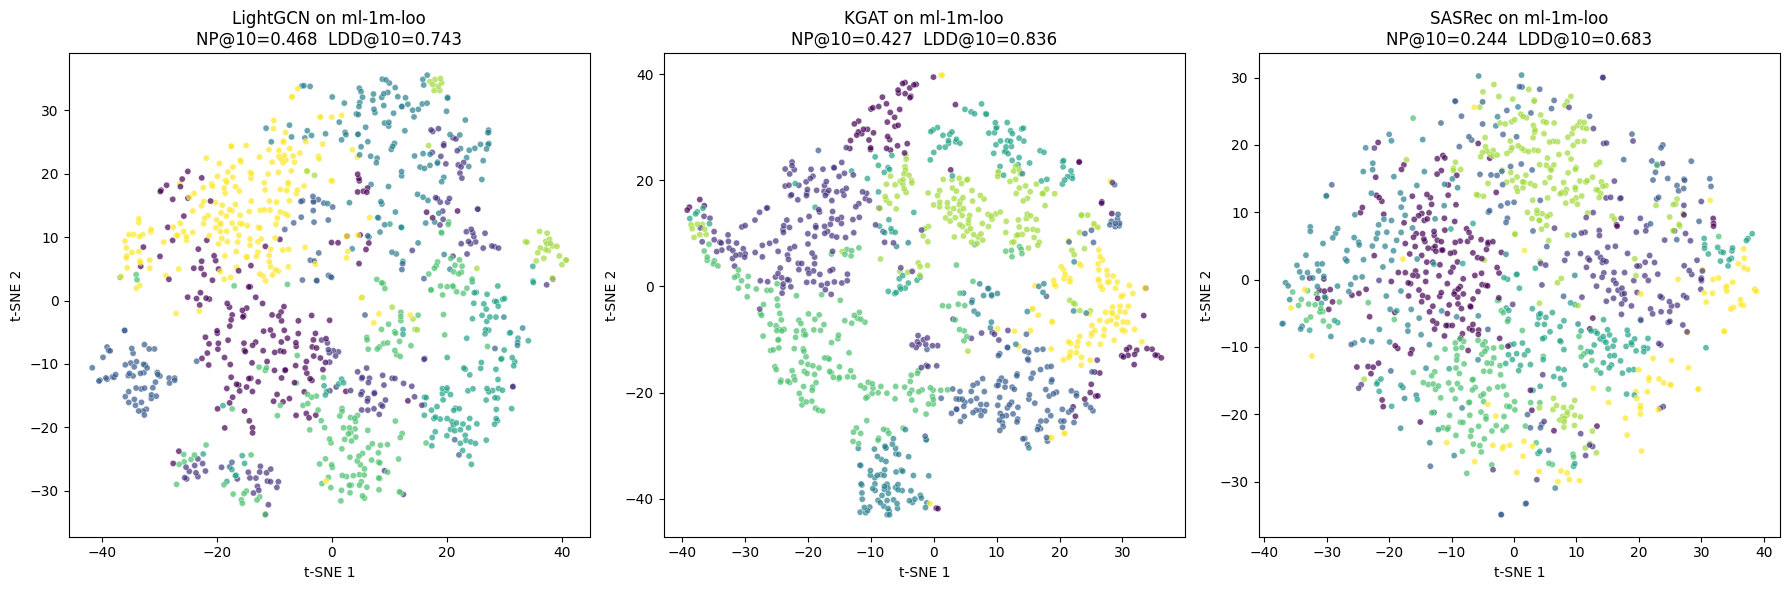

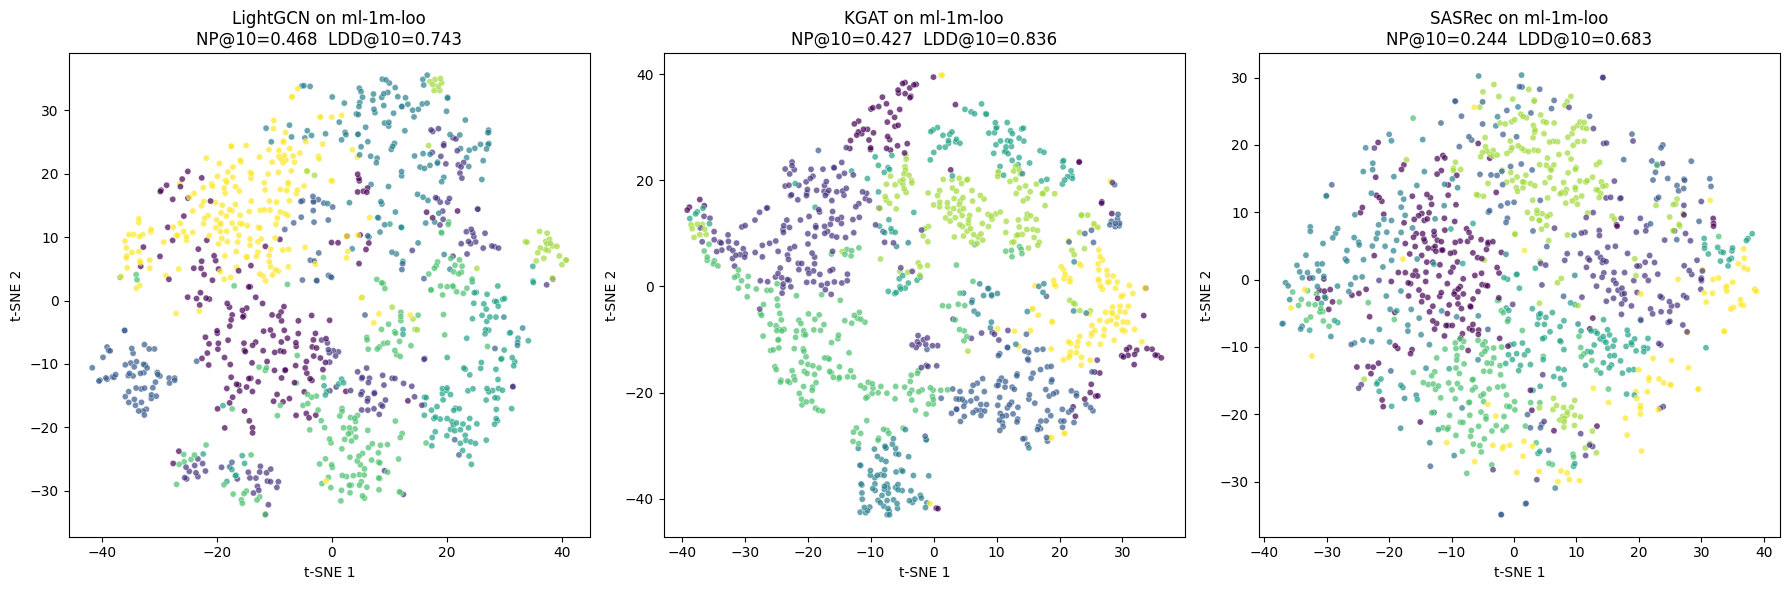

In [29]:
# Tabela A — next-item prediction em ML-1M, 3 modelos, 3 seeds
table_a, results_a, geom_a = run_table_a(
    seeds=SEEDS,
    dataset='ml-1m-loo',
    lightgcn_epochs=1000,
    kgat_epochs=1000,
    sasrec_epochs=200,
)
save_results(
    {'table_a': table_a},
    Path(SAVE_DIR) / 'table_a.json',
    hyperparameters=get_hyperparameters('chronological_loo', 'ml-1m-loo'),
)
format_table(table_a, models=['lightgcn', 'kgat', 'sasrec'],
             metrics=('hr@10', 'recall@10', 'ndcg@10', 'recall@20', 'ndcg@20'))
format_geom_table(geom_a, dataset_name='ml-1m-loo')
plot_tsne_grid(
    geom_a[SEEDS[0]],
    save_path=Path(SAVE_DIR) / 'tsne_ml-1m-loo.png',
    save_individuals=True,
)


######################################################################
# DATASET: ml-1m-random
######################################################################

[Table B | ml-1m-random | seed 2020] LightGCN ...
  ml-1m-random: 6040 users, 3416 items, 797275 train, 202336 test, density=3.8641%
  ep  10  loss=0.3062  R@20=0.1435  N@10=0.2699  HR@10=0.7627
  ep  20  loss=0.2544  R@20=0.1755  N@10=0.3164  HR@10=0.8217
  ep  30  loss=0.2306  R@20=0.1952  N@10=0.3427  HR@10=0.8543
  ep  40  loss=0.2163  R@20=0.2095  N@10=0.3583  HR@10=0.8685
  ep  50  loss=0.2060  R@20=0.2173  N@10=0.3677  HR@10=0.8790
  ep  60  loss=0.1972  R@20=0.2234  N@10=0.3733  HR@10=0.8868
  ep  70  loss=0.1906  R@20=0.2278  N@10=0.3778  HR@10=0.8945
  ep  80  loss=0.1835  R@20=0.2313  N@10=0.3810  HR@10=0.8987
  ep  90  loss=0.1778  R@20=0.2340  N@10=0.3846  HR@10=0.9033
  ep 100  loss=0.1719  R@20=0.2359  N@10=0.3888  HR@10=0.9043
  ep 110  loss=0.1658  R@20=0.2387  N@10=0.3898  HR@10=0.9070
  ep 120  loss=0.

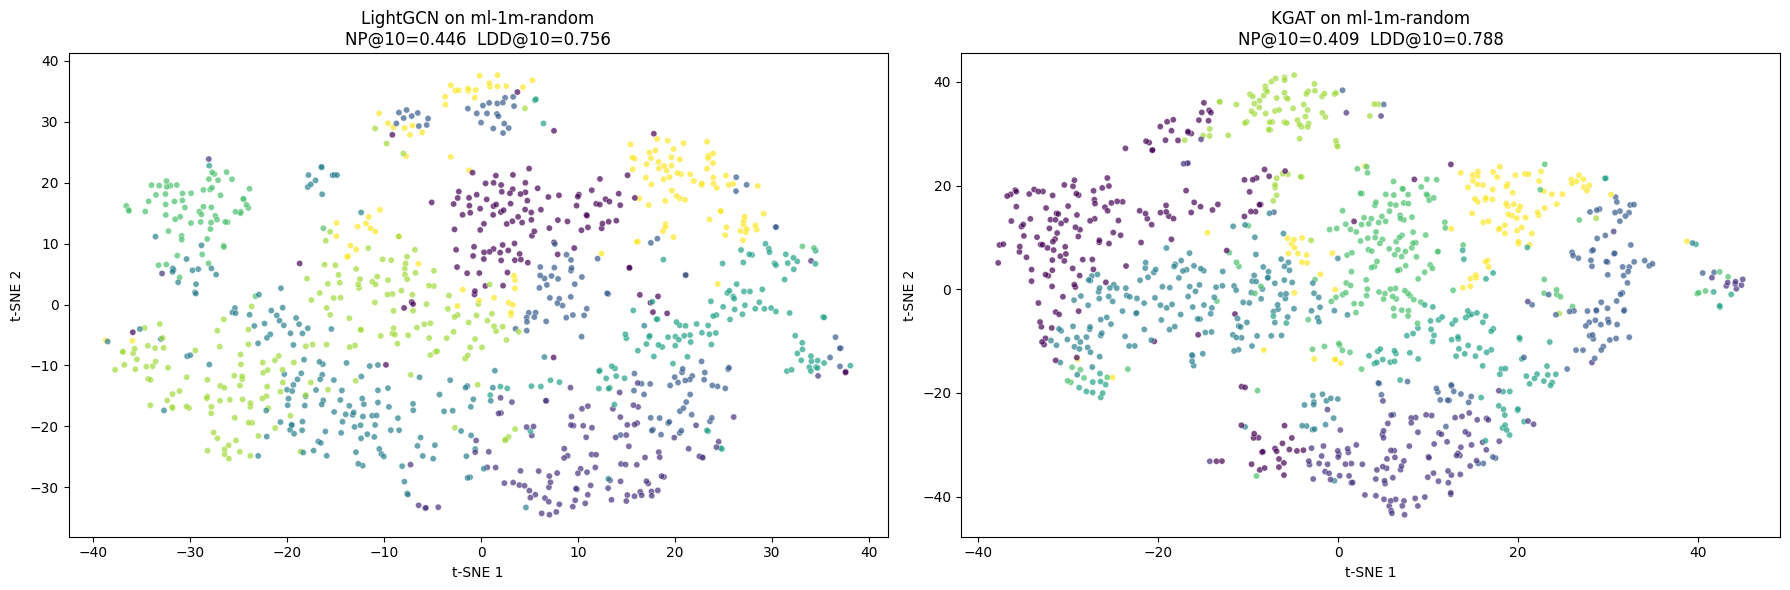

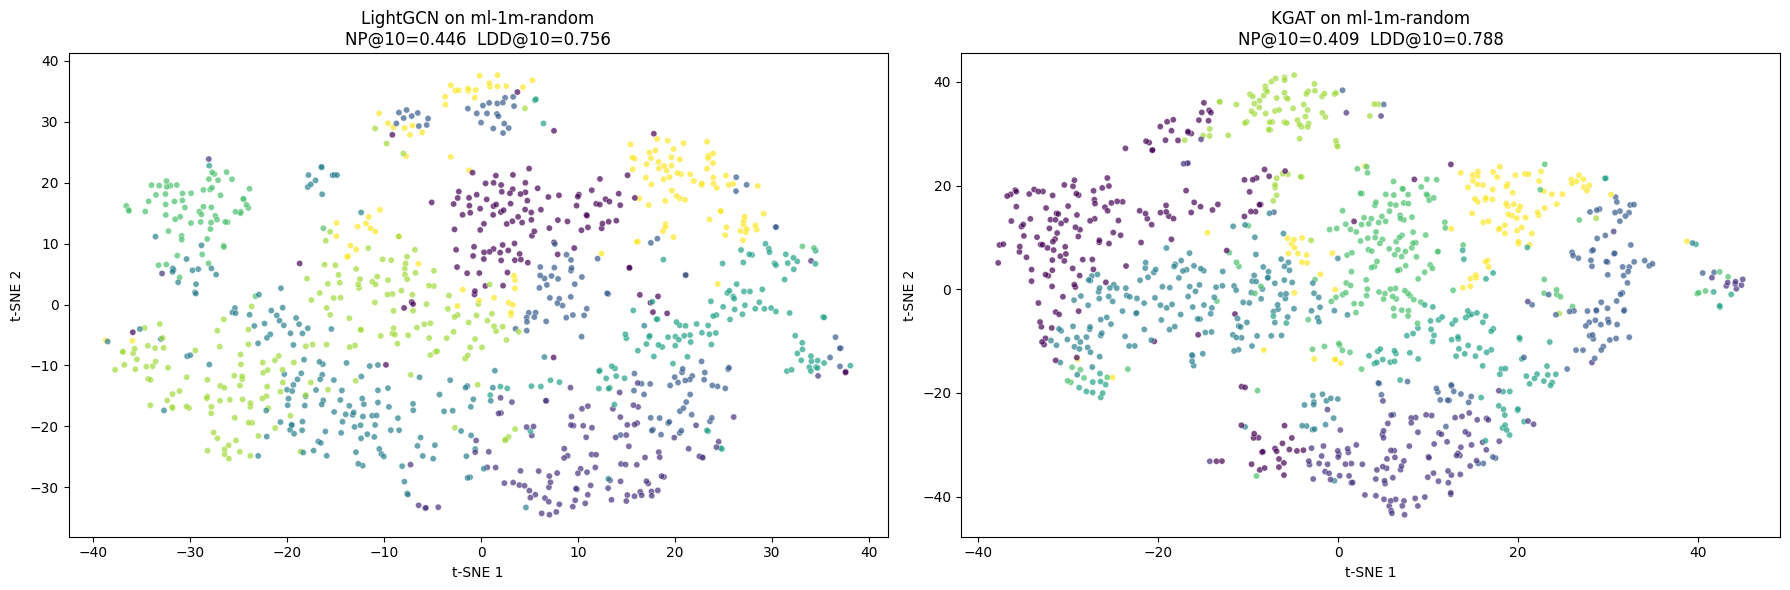

In [30]:
table_b_ml1m, results_b_ml1m, geom_b_ml1m = run_table_b(
    seeds=SEEDS,
    datasets=('ml-1m-random',),
    lightgcn_epochs=1000,
    kgat_epochs=1000,
)
save_results({'table_b_ml1m': table_b_ml1m}, Path(SAVE_DIR) / 'table_b_ml1m.json')
format_table(table_b_ml1m, models=['lightgcn', 'kgat'], datasets=('ml-1m-random',),
             metrics=('hr@10', 'recall@10', 'ndcg@10', 'recall@20', 'ndcg@20'))
format_geom_table(geom_b_ml1m)
plot_tsne_grid(geom_b_ml1m['ml-1m-random'][SEEDS[0]],
               save_path=Path(SAVE_DIR) / 'tsne_ml-1m-random.png')

In [ ]:
table_b_yelp, results_b_yelp, geom_b_yelp = run_table_b(
    seeds=SEEDS,
    datasets=('yelp2018',),
    lightgcn_epochs=1000,
    kgat_epochs=1000,
)
save_results({'table_b_yelp': table_b_yelp}, Path(SAVE_DIR) / 'table_b_yelp.json')
format_table(table_b_yelp, models=['lightgcn', 'kgat'], datasets=('yelp2018',))
format_geom_table(geom_b_yelp)
plot_tsne_grid(geom_b_yelp['yelp2018'][SEEDS[0]],
               save_path=Path(SAVE_DIR) / 'tsne_yelp2018.png')


######################################################################
# DATASET: yelp2018
######################################################################

[Table B | yelp2018 | seed 2020] LightGCN ...
  yelp2018: 45919 users, 45538 items, 930032 train, 253578 test, density=0.0445%
  ep  10  loss=0.1084  R@20=0.0469  N@10=0.0239  HR@10=0.1210
  ep  20  loss=0.0841  R@20=0.0503  N@10=0.0253  HR@10=0.1296
  ep  30  loss=0.0699  R@20=0.0535  N@10=0.0271  HR@10=0.1379
  ep  40  loss=0.0592  R@20=0.0562  N@10=0.0282  HR@10=0.1426
  ep  50  loss=0.0509  R@20=0.0590  N@10=0.0296  HR@10=0.1486
  ep  60  loss=0.0451  R@20=0.0611  N@10=0.0306  HR@10=0.1550
  ep  70  loss=0.0400  R@20=0.0624  N@10=0.0314  HR@10=0.1576
  ep  80  loss=0.0362  R@20=0.0642  N@10=0.0323  HR@10=0.1612
  ep  90  loss=0.0328  R@20=0.0655  N@10=0.0330  HR@10=0.1636
  ep 100  loss=0.0301  R@20=0.0663  N@10=0.0337  HR@10=0.1664
  ep 110  loss=0.0277  R@20=0.0677  N@10=0.0343  HR@10=0.1690
  ep 120  loss=0.0258  R@20

In [32]:
# Recupera KGAT seed 2022 (yelp2018) — único item perdido no crash
SEED = 2022

print(f"[Recovery] KGAT yelp2018 seed {SEED} ...")
r_kg = train_kgat(
    DATA_ROOT / 'yelp2018',
    seed=SEED,
    epochs=1000,
    eval_every=5,
    patience=10,
)

# Análise geométrica para essa seed
emb = kgat_item_embeddings(r_kg)
g = run_geometric_analysis(
    item_embeddings=emb,
    train_dict=r_kg['dataset'].train_dict,
    n_items=r_kg['dataset'].n_items,
    model_name='KGAT',
    dataset_name='yelp2018',
    k=10, n_samples=1000, seed=SEED,
    run_tsne=False,    # já temos o t-SNE da seed 2020
)
print(f"\n  KGAT seed {SEED}: NP@10={g['NP@k']:.4f}  LDD@10={g['LDD@k']:.4f}")
print(f"  KGAT seed {SEED}: R@20={r_kg['best']['recall@20']:.4f}  "
      f"NDCG@10={r_kg['best']['ndcg@10']:.4f}  HR@10={r_kg['best']['hr@10']:.4f}")

# Salvar como recovery atômico para o caso de algo dar errado depois
save_results(
    {
        'kgat_yelp2018_seed_2022': {
            'best': r_kg['best'],
            'geometric': {
                'NP@10': float(g['NP@k']),
                'LDD@10': float(g['LDD@k']),
            },
        },
    },
    Path(SAVE_DIR) / 'kgat_yelp_seed_2022_recovery.json',
    hyperparameters=get_hyperparameters('random_80_20', 'yelp2018', seeds=[SEED]),
)

[Recovery] KGAT yelp2018 seed 2022 ...
  yelp2018: n_users=45919, n_items=45538, n_entities=136499, n_relations=85
    n_cf_train=930032, n_kg_triples=3707408
  ep  5 (35.6s)  cf=0.3292 kg=0.2061  R@20=0.0173  N@10=0.0086  HR@10=0.0498
  ep 10 (35.8s)  cf=0.2425 kg=0.1647  R@20=0.0215  N@10=0.0108  HR@10=0.0622
  ep 15 (35.7s)  cf=0.1930 kg=0.1459  R@20=0.0253  N@10=0.0124  HR@10=0.0711
  ep 20 (35.8s)  cf=0.1769 kg=0.1303  R@20=0.0260  N@10=0.0130  HR@10=0.0722
  ep 25 (35.8s)  cf=0.1701 kg=0.1197  R@20=0.0265  N@10=0.0130  HR@10=0.0741
  ep 30 (35.8s)  cf=0.1662 kg=0.1110  R@20=0.0272  N@10=0.0130  HR@10=0.0736
  ep 35 (35.8s)  cf=0.1646 kg=0.1038  R@20=0.0289  N@10=0.0141  HR@10=0.0792
  ep 40 (35.8s)  cf=0.1620 kg=0.0976  R@20=0.0301  N@10=0.0143  HR@10=0.0800
  ep 45 (35.8s)  cf=0.1599 kg=0.0921  R@20=0.0315  N@10=0.0150  HR@10=0.0826
  ep 50 (35.8s)  cf=0.1570 kg=0.0878  R@20=0.0323  N@10=0.0157  HR@10=0.0854
  ep 55 (35.8s)  cf=0.1552 kg=0.0844  R@20=0.0333  N@10=0.0159  HR@10=0


######################################################################
# DATASET: amazon-book
######################################################################

[Table B | amazon-book | seed 2020] LightGCN ...
  amazon-book: 70679 users, 24915 items, 652514 train, 193920 test, density=0.0371%
  ep  10  loss=0.1642  R@20=0.0853  N@10=0.0345  HR@10=0.1050
  ep  20  loss=0.1074  R@20=0.0956  N@10=0.0382  HR@10=0.1159
  ep  30  loss=0.0786  R@20=0.1033  N@10=0.0412  HR@10=0.1247
  ep  40  loss=0.0619  R@20=0.1111  N@10=0.0443  HR@10=0.1331
  ep  50  loss=0.0496  R@20=0.1166  N@10=0.0469  HR@10=0.1389
  ep  60  loss=0.0410  R@20=0.1229  N@10=0.0492  HR@10=0.1447
  ep  70  loss=0.0349  R@20=0.1270  N@10=0.0512  HR@10=0.1504
  ep  80  loss=0.0298  R@20=0.1299  N@10=0.0526  HR@10=0.1539
  ep  90  loss=0.0264  R@20=0.1325  N@10=0.0542  HR@10=0.1576
  ep 100  loss=0.0238  R@20=0.1345  N@10=0.0550  HR@10=0.1599
  ep 110  loss=0.0216  R@20=0.1355  N@10=0.0557  HR@10=0.1616
  ep 120  loss=0.0

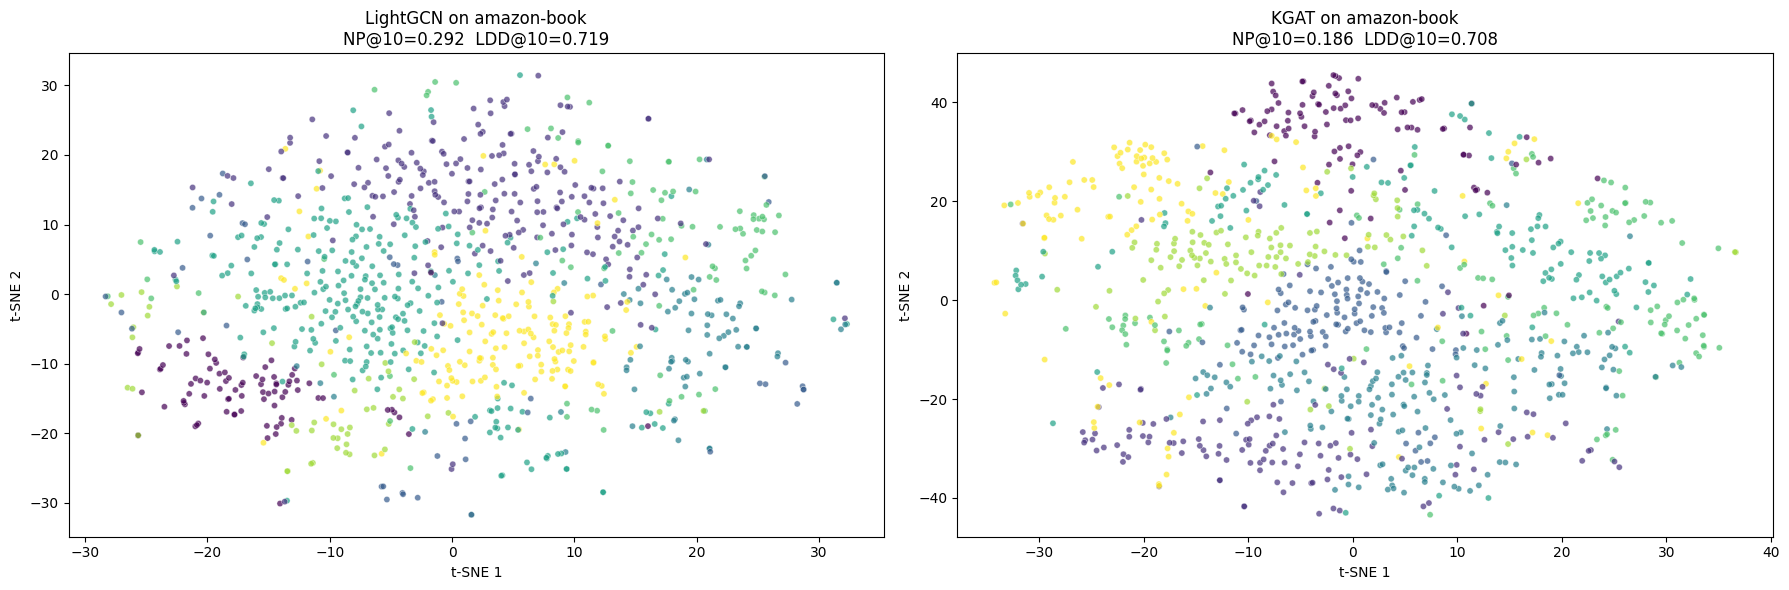

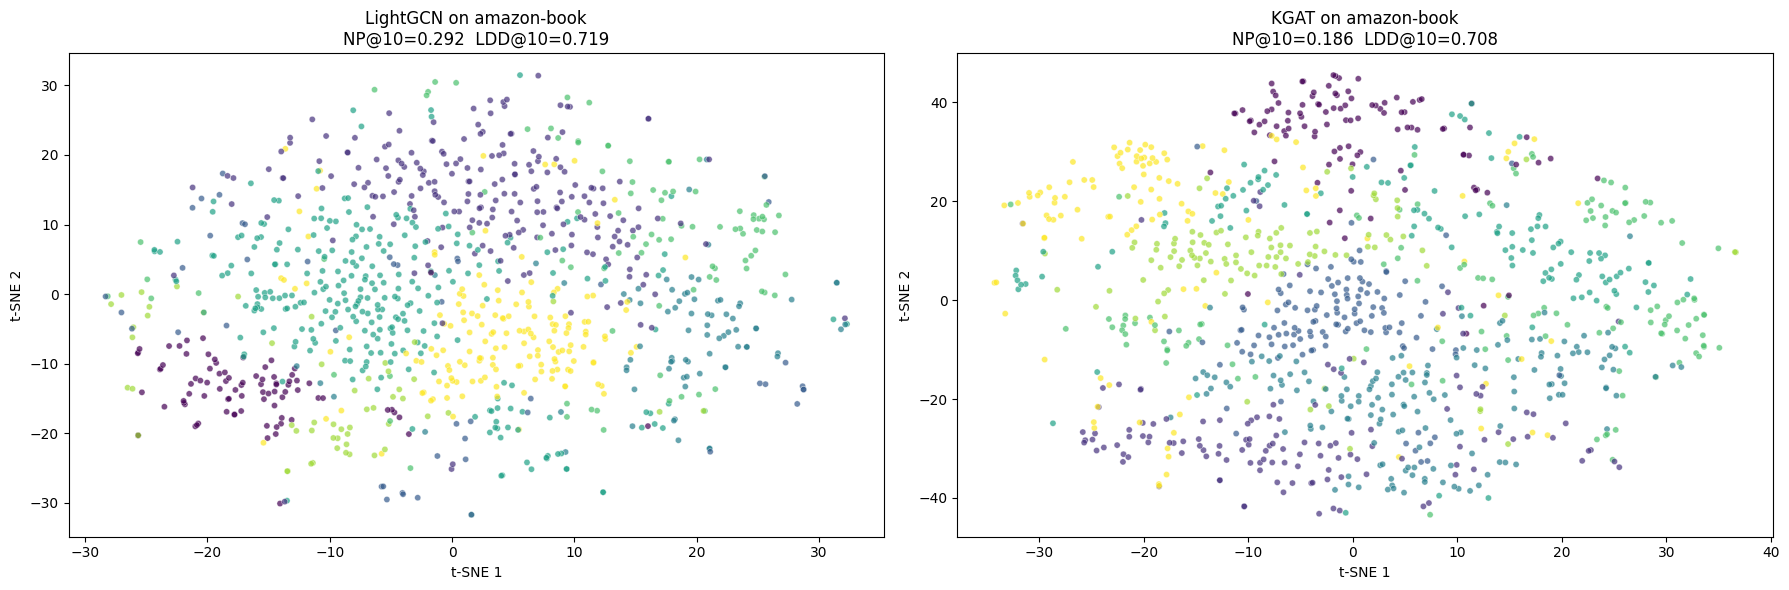

In [36]:
table_b_amazon, results_b_amazon, geom_b_amazon = run_table_b(
    seeds=[2020],
    datasets=('amazon-book',),
    lightgcn_epochs=1000,
    kgat_epochs=1000,
)
save_results(
    {'table_b_amazon': table_b_amazon},
    Path(SAVE_DIR) / 'table_b_amazon.json',
    hyperparameters=get_hyperparameters('random_80_20', 'amazon-book', seeds=[2020]),
)
format_table(table_b_amazon, models=['lightgcn', 'kgat'], datasets=('amazon-book',),
             metrics=('hr@10', 'recall@10', 'ndcg@10', 'recall@20', 'ndcg@20'))
format_geom_table(geom_b_amazon)
plot_tsne_grid(geom_b_amazon['amazon-book'][2020],
               save_path=Path(SAVE_DIR) / 'tsne_amazon-book.png',
               save_individuals=True)

In [ ]:
SEED_THIS_SESSION = 2022

table_b_amz, results_b_amz, geom_b_amz = run_table_b(
    seeds=[SEED_THIS_SESSION],
    datasets=('amazon-book',),
    lightgcn_epochs=1000,
    kgat_epochs=1000,
)
save_results({f'table_b_amazon_seed{SEED_THIS_SESSION}': table_b_amz},
             Path(SAVE_DIR) / f'table_b_amazon_seed{SEED_THIS_SESSION}.json')
format_table(table_b_amz, models=['lightgcn', 'kgat'], datasets=('amazon-book',))
format_geom_table(geom_b_amz)
if SEED_THIS_SESSION == SEEDS[0]:
    plot_tsne_grid(geom_b_amz['amazon-book'][SEED_THIS_SESSION],
                   save_path=Path(SAVE_DIR) / 'tsne_amazon-book.png')

In [ ]:
SEED_THIS_SESSION = 2022

table_b_amz, results_b_amz, geom_b_amz = run_table_b(
    seeds=[SEED_THIS_SESSION],
    datasets=('amazon-book',),
    lightgcn_epochs=1000,
    kgat_epochs=1000,
)
save_results({f'table_b_amazon_seed{SEED_THIS_SESSION}': table_b_amz},
             Path(SAVE_DIR) / f'table_b_amazon_seed{SEED_THIS_SESSION}.json')
format_table(table_b_amz, models=['lightgcn', 'kgat'], datasets=('amazon-book',))
format_geom_table(geom_b_amz)
if SEED_THIS_SESSION == SEEDS[0]:
    plot_tsne_grid(geom_b_amz['amazon-book'][SEED_THIS_SESSION],
                   save_path=Path(SAVE_DIR) / 'tsne_amazon-book.png')